# Optimización Nutricional de la Canasta Básica Alimentaria Urbana (Guatemala)

"La CBA es un conjunto de alimentos que constituyen un **mínimo necesario** para satisfacer
al menos las necesidades energéticas y proteínicas de una persona; y que se ajustan al patrón
cultural, capacidad adquisitiva y la disponibilidad y precios de los alimentos a nivel local."

La CBA cubre necesidades energéticas y proteínicas básicas, pero no garantiza una nutrición
balanceada. Las Recomendaciones Dietéticas Diarias del INCAP (2012) establecen los rangos
de referencia por nutriente para la población centroamericana.

**Objetivo**: Dado el conjunto de alimentos que componen la CBA urbana actual, redistribuir
sus porciones mensuales para maximizar simultáneamente el valor nutricional y la adecuación
energética, minimizando el costo — sin agregar ni eliminar productos.

No se asume un perfil de persona. En su lugar, se optimiza contra los rangos normativos
del INCAP como función objetivo, evaluando qué tan cerca está cada solución del espacio
nutricional deseable.

### Formulación del problema

Se busca un vector de porciones $\mathbf{x} = [x_1, x_2, \dots, x_n]$ (gramos/mes por
alimento) que resuelva:

$$\min_{\mathbf{x}} \; \mathcal{L}(\mathbf{x}) = w_{\text{costo}} \cdot C(\mathbf{x}) - w_{\text{nutr}} \cdot S(\mathbf{x}) - w_{e} \cdot E(\mathbf{x})$$

Donde:
- $C(\mathbf{x})$ es el costo total mensual de la canasta
- $S(\mathbf{x})$ es el puntaje de adecuación nutricional agregado sobre micronutrientes y macronutrientes
- $E(\mathbf{x})$ es el puntaje de adecuación energética
- $w_{\text{costo}},\, w_{\text{nutr}},\, w_{e}$ son pesos configurables según la importancia relativa

La energía se separa de $S(\mathbf{x})$ porque es la restricción más estructural de la dieta:
sin adecuación energética, el resto de la optimización pierde sentido biológico. Su peso
propio $w_e$ permite calibrar qué tan dominante es frente al puntaje nutricional y el costo.

### Puntaje de adecuación energética $E(\mathbf{x})$

$$E(\mathbf{x}) = \begin{cases}
1 & \text{si } \text{kcal}_{\min} \leq \text{Energía}(\mathbf{x}) \leq \text{kcal}_{\max} \\
1 - \dfrac{|\text{Energía}(\mathbf{x}) - \text{kcal}_{\text{centro}}|}{\tau_e} & \text{fuera del rango, dentro de tolerancia} \\
0 & \text{fuera de tolerancia}
\end{cases}$$

### Puntaje de adecuación nutricional $S(\mathbf{x})$

Para cada nutriente $n$, se define su adecuación como:

$$a_n(\mathbf{x}) = \frac{\text{Ingesta}_n(\mathbf{x})}{\text{RDD}_n}$$

El puntaje penaliza tanto el déficit como el exceso, con una tolerancia $\tau$ configurable
alrededor del rango óptimo $[L_n,\, U_n]$:

$$s_n = \begin{cases}
1 & \text{si } L_n \leq a_n \leq U_n \\
1 - \dfrac{|a_n - \text{centro}_n|}{\tau} & \text{si fuera del rango, dentro de tolerancia} \\
0 & \text{si fuera de tolerancia}
\end{cases}$$

$$S(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^{N} s_n$$

Las tolerancias $\tau$ y $\tau_e$ son parámetros ajustables — más altas durante la
exploración, más estrictas en la evaluación final de cada solución.

### Nutrientes incluidos en $S(\mathbf{x})$

| Grupo | Nutrientes |
|---|---|
| Macronutrientes | Proteína, Carbohidratos, Fibra, Grasa total, AG saturados |
| Minerales críticos (GT) | Hierro, Zinc, Calcio, Sodio (límite superior) |
| Vitaminas críticas (GT) | Vitamina A, Vitamina C, Folatos, Vitamina B12 |

### Restricciones duras

$$C(\mathbf{x}) \leq Q924 \qquad x_i \geq 0 \;\; \forall i$$

El presupuesto es la única restricción fija. Los rangos nutricionales y la adecuación
energética entran como penalizaciones en la función objetivo — no como restricciones
duras — lo que permite al solver explorar libremente y revelar los trade-offs reales
entre costo, energía y nutrición.

## Carga de datos INCAP - Datos Nutricionales
Para ello utilizamos como referencia el documento del INCAP *Tabla de composición de alimentos de Centroamerica - Tercera Edición 2018*. La fuente es un pdf.

In [393]:
!pip install pandas pdfplumber scipy


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [394]:
import pdfplumber
import pandas as pd
import json
import numpy as np
""" import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted') """

" import matplotlib.pyplot as plt\nimport matplotlib.ticker as mticker\nimport seaborn as sns\nimport warnings\n\nwarnings.filterwarnings('ignore')\nplt.rcParams['figure.dpi'] = 120\nplt.rcParams['font.family'] = 'DejaVu Sans'\nsns.set_theme(style='whitegrid', palette='muted') "

In [395]:

"""
Se identifican dos secciones nutricionales de cada alimentos: 
1. Macro nutrientes
2. Vitaminas (micro nutrientes)

Cada tabla con sus campos o columnas. 

"""
COLS_MACRO = [
    "codigo", "nombre", "agua_pct", "energia_kcal",
    "proteina_g", "grasa_total_g", "ag_sat_g", "ag_mono_g", "ag_poli_g",
    "colesterol_mg", "carbohidratos_g", "azucares_g", "ceniza_g",
    "fibra_dietetica_g", "calcio_mg", "hierro_mg", "magnesio_mg",
    "fosforo_mg", "potasio_mg", "sodio_mg", "zinc_mg", "cobre_mg",
    "selenio_mcg", "fraccion_comestible_pct", "_extra",
]
 
COLS_VITA = [
    "_blank", "codigo", "nombre", "energia_kcal",
    "vitamina_c_mg", "tiamina_mg", "riboflavina_mg", "niacina_mg",
    "ac_pantotenico_mg", "vitamina_b6_mg", "ac_folico_mcg",
    "folato_alimentos_mcg", "folato_fde_mcg", "vitamina_b12_mcg",
    "vitamina_a_rae_mcg", "retinol_mcg", "b_carotenos_mcg",
    "vitamina_e_mg", "vitamina_d_mcg", "vitamina_k_mcg",
    "fraccion_comestible_pct",
]

In [396]:
def get_row_type(row, codigo_idx):
    """
    Devuelve un string indicando el tipo de fila que es. 
    - Category
    - Alimento (data)
    - Other (Fila cabecera)
    
    """
    if not row or len(row) <= codigo_idx:
        return False
    try:
        code: str = str(row[codigo_idx] or "").strip() 
        int(code)
        is_category = len(code)<=2 # and len(code)>0 

        return "category" if is_category else "data"
    except ValueError:
        return "other" # Titulos de tablas
 
 
def extract_row(table, cols, codigo_idx, categories=None):
    """Extrae filas de datos de una página y las mapea a los nombres de columna."""

    filas = []
    for row in table:
        row_type = get_row_type(row, codigo_idx) 
        if row_type == "data":
            # Rellenar si la fila tiene menos columnas de lo esperado
            padded = list(row) + [None] * max(0, len(cols) - len(row))
            record = {}
            for col, val in zip(cols, padded):
                if col.startswith("_"):
                    continue
                record[col] = str(val).strip() if val else None
            filas.append(record)
        elif row_type == "category": 
            if not categories is None:
                code = int(row[codigo_idx])
                categories[code] = row[codigo_idx+1]
            
    return filas
 
 
def detect_page_type(table):
    """
    Devuelve 'macro', 'vita' o None según el número de columnas.
    Macro: 25 cols, codigo en índice 0.
    Vita:  21 cols, codigo en índice 1 (índice 0 es blanco, segun se observo de pruebas inciales).
    """
    if not table or len(table) < 3:
        return None
    ncols = len(table[0])
    if ncols == 25:
        return "macro"
    if ncols == 21:
        return "vita"
    return None
 

def process_pdf(pdf_path, start_page=26, show_logs = True):

    """
    Procesamiento de pdf, utilizando funciones auxiliares definidias. 
    """
    print(f"Abriendo: {pdf_path}")

    macro_records = {}
    vita_records  = {}
    categories = {}

    with pdfplumber.open(pdf_path) as pdf:
        total = len(pdf.pages) 
        print(f"Total páginas: {total} | Procesando desde página {start_page}\n")

        for i in range(start_page - 1, total):
            page = pdf.pages[i]
            tables = page.extract_tables()
            if not tables:
                print(f"Pagina {page} sin tabla")
                continue
            # Filtrar tablas validas, solo debe haber una tabla valida por pagina. Validamos por el numero de columnas

            nutrition_tables = [_table for _table in tables if len(_table[0])>20]  
            if len(nutrition_tables)!=1:
                if len(nutrition_tables)==0: 
                    print(f"Pagina {page} sin tabla de nutricion valida")
                    continue
                else: 
                    print(f"Pagina Invalida {page}")# Esto no pasa
                    raise ValueError(f"Pagina Invalida {page}")
                print(nutrition_tables)
            
            table = nutrition_tables[0]
            tipo = detect_page_type(table)

            if tipo == "macro":
                for f in extract_row(table, COLS_MACRO, codigo_idx=0, categories=categories):
                    macro_records[f["codigo"]] = f

            elif tipo == "vita":
                for f in extract_row(table, COLS_VITA, codigo_idx=1, categories=categories):
                    vita_records[f["codigo"]] = f

            if show_logs and (i + 1) % 50 == 0:
                print(f"Página {i+1}/{total}  |  macro={len(macro_records)}  vita={len(vita_records)}")

    if show_logs: 
        print(f"\nRegistros macro: {len(macro_records)}")
        print(f"Registros vita:  {len(vita_records)}")
        print(f"Categorias: {categories}")

    codes = set(macro_records) | set(vita_records)
    rows = []
    for cod in sorted(codes, key=lambda x: int(x) if x and x.isdigit() else 0):
        m = macro_records.get(cod, {})
        v = vita_records.get(cod, {})

        name = " ".join((m.get("nombre") or v.get("nombre") or "").split())

        fila = {"codigo": cod, "nombre": name}

        for k, val in m.items():
            if k not in ("codigo", "nombre"):
                fila[k] = val

        for k, val in v.items():
            if k not in ("codigo", "nombre", "energia_kcal", "fraccion_comestible_pct"):
                fila[k] = val

        rows.append(fila)

    df = pd.DataFrame(rows)

    firsts = ["codigo", "nombre", "energia_kcal", "agua_pct", "fraccion_comestible_pct"]
    others = [c for c in df.columns if c not in firsts]

    df = df[[c for c in firsts if c in df.columns] + others]
    return df, categories
    

In [397]:
import pickle 

composition_table_food_df_serialized_filename = "./cache/composition_table_food_df.pkl"
categories_serialized_filename = "./cache/categories.pkl"
incap_pdf = "./data/raw/tabladecomposiciondealimentos.pdf"

try: 
    with open(composition_table_food_df_serialized_filename, 'rb') as f:
        composition_table_food_df = pickle.load(f) 

    with open(categories_serialized_filename, 'rb') as f:
        categories = pickle.load(f) 

    print("Loaded data from cache serialized data")
except:
    print(f"Couldn't find cache data. Extracting data from {incap_pdf}")
    composition_table_food_df, categories = process_pdf(incap_pdf, 26)

    with open(composition_table_food_df_serialized_filename, 'wb') as f:
        pickle.dump(composition_table_food_df, f) 

    with open(categories_serialized_filename, 'wb') as f:
        pickle.dump(categories, f) 

print(composition_table_food_df)
print(categories)


Loaded data from cache serialized data
     codigo                                      nombre energia_kcal agua_pct  \
0      1001                               CREMA, ESPESA          340       58   
1      1002                                 CREMA, RALA          292       64   
2      1003        CREMA, SUSTITUTO NO LACTEO, EN POLVO          529        3   
3      1004                      LECHE DE BURRA, FLUIDA           43       90   
4      1005             LECHE DE CABRA, FLUIDA, C/VIT D           69       87   
...     ...                                         ...          ...      ...   
2652  25073      PAN BLANCO, SIN GLUTEN, SANDWICH SUAVE          298       34   
2653  25074                PAN, BAJO EN CALORIAS, AVENA          210       44   
2654  25075     PAN, BAJO EN CALORIAS, SALVADO DE AVENA          201       46   
2655  25076                PAN, BAJO EN CALORIAS, TRIGO          217       40   
2656  25077  BOLLOS, SIN GLUTEN (ARROZ, TAPIOCA Y PAPA)          310  

In [398]:
composition_table_food_df['codigo'] = composition_table_food_df['codigo'].astype(str)
composition_table_food_df['category'] = composition_table_food_df['codigo'].str[:-3]
composition_table_food_df[['category', 'codigo', 'nombre']]


,category,codigo,nombre
0,1,1001,"CREMA, ESPESA"
1,1,1002,"CREMA, RALA"
2,1,1003,"CREMA, SUSTITUTO NO LACTEO, EN POLVO"
3,1,1004,"LECHE DE BURRA, FLUIDA"
4,1,1005,"LECHE DE CABRA, FLUIDA, C/VIT D"
...,...,...,...
2652,25,25073,"PAN BLANCO, SIN GLUTEN, SANDWICH SUAVE"
2653,25,25074,"PAN, BAJO EN CALORIAS, AVENA"
2654,25,25075,"PAN, BAJO EN CALORIAS, SALVADO DE AVENA"
2655,25,25076,"PAN, BAJO EN CALORIAS, TRIGO"


In [399]:
composition_table_food_df['energia_kcal'] = pd.to_numeric(composition_table_food_df['energia_kcal'], errors='coerce')


## Carga de datos CBA

In [400]:
"""
CREAR CBA DF mergeado sin repetir producto
En el que se calcule el valor de kcal por 100g. 

Servira luego para comparar con INCAP. 
.
"""
import pandas as pd
from typing import List, Tuple, Dict
from pydantic import BaseModel, ConfigDict, field_validator, model_validator
from dataclasses import dataclass

MONTHS = [
    'enero', 
    'febrero',
    'marzo', 
    'abril', 
    'mayo',
    'junio',
    'julio',
    'agosto',
    'septiembre',
    'octubre',
    'noviembre',
    'diciembre' 
]

class CBADataSource(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)  # necesario para pd.DataFrame

    data: pd.DataFrame
    region: str
    start_month: Tuple[int, str]  
    end_month: Tuple[int, str]  

    @field_validator('start_month', 'end_month')
    @classmethod
    def validate_year_month(cls, value: Tuple[int, str]  ) -> Tuple[int, str]  :
        year, month = value
        
        if not isinstance(year, int) or year < 1900:
            raise ValueError(f"Año inválido '{year}': debe ser un entero mayor a 1900")
        
        normalized = month.strip().lower()
        if normalized not in MONTHS:
            raise ValueError(f"Mes inválido '{month}'. Opciones: {MONTHS}")
        
        return (year, normalized)

    @model_validator(mode='after')
    def validate_range(self) -> 'CBADataSource':
        start_year, start_month = self.start_month
        end_year, end_month = self.end_month

        start_idx = (start_year, MONTHS.index(start_month))
        end_idx   = (end_year,   MONTHS.index(end_month))

        if start_idx > end_idx:
            raise ValueError(
                f"El inicio '{start_month} {start_year}' "
                f"no puede ser posterior al fin '{end_month} {end_year}'"
            )
        return self

@dataclass
class ProductTLItem: 
    month: Tuple[int, int] 
    kcal: float
    grams: float
    kcal_per100_gram: float
    monthly_cost: float

MONTHS = [
    'enero', 
    'febrero',
    'marzo', 
    'abril', 
    'mayo',
    'junio',
    'julio',
    'agosto',
    'septiembre',
    'octubre',
    'noviembre',
    'diciembre' 
]
@dataclass
class Product:
    name: str
    kcal_per100_gram: float
    category: str
    initial_source_start_month: Tuple[int, str]  
    initial_source_end_month: Tuple[int, str]  
    timelines: Dict[str, List[ProductTLItem]] # Region: Timeline list

    def __init__(self, initial_source: pd.Series, start_month: Tuple[int, str], end_month: Tuple[int, str], initial_source_region: str):
        self.name = initial_source['Product']
        self.kcal_per100_gram = (initial_source['Kcal Per Person']*100*(365/12))/initial_source['Grams Monthly']
        self.category = initial_source['Category']
        self.initial_source_start_month = start_month
        self.initial_source_end_month = end_month 

        self.timelines = {}
        # Asume que no hay meses de por medio.
        self.add_tl_item(initial_source, start_month, initial_source_region, 1)
        self.add_tl_item(initial_source, end_month, initial_source_region, 2)

    def add_tl_item(self, data: pd.Series, month: Tuple[int, str], region: str, relative_month_no: int):

        month = (month[0], MONTHS.index(month[1]))

        tl_item = ProductTLItem(
            month=month,
            kcal=data['Kcal Per Person'],
            grams=data['Grams Monthly'],
            kcal_per100_gram=(data['Kcal Per Person'] * 100) / data['Grams Monthly'],
            monthly_cost=data[f'Monthly Cost {relative_month_no}']
        )
        if not region in self.timelines:
            self.timelines[region] = [tl_item]
            return
            

        
        for i, item in enumerate(self.timelines[region]):            
            if month < item.month:
                self.timelines[region].insert(i, tl_item)
                return
        
        self.timelines[region].append(tl_item)
    
class CBAData:
    def __init__(self, sources: List[CBADataSource]):
        self.sources:List[CBADataSource] = []
        self.products: Dict[str, Product] = {}# Como dict para facilitar la busqueda
        self.EXPECTED_COLUMNS = [
            'Category',
            'Product',
            'Kcal Per Person',
            'Grams Monthly',
            'Monthly Cost 1',
            'Monthly Cost 2'
        ]
        self.categories: Dict[str, List[str]]
        self.__validate_data_sources(sources)
        for source in sources: 
            self.__load_products(source)
        self.sources = sources


    def __validate_data_source(self, source: CBADataSource):
        df = source.data

        if source.start_month[0] > source.end_month[0]: 
            raise ValueError(
                f"Rango invalido ({source.start_month}-{source.end_month})"
            )
        elif source.start_month[0] == source.end_month[0]:
            if MONTHS.index(source.start_month[1]) >= MONTHS.index(source.end_month[1]):
                raise ValueError(
                f"Rango invalido ({source.start_month}-{source.end_month})"
                )
        missing_columns = [col for col in self.EXPECTED_COLUMNS if col not in df.columns]

        if missing_columns:
            raise ValueError(
                f"La fuente de la región '{source.region}' ({source.start_month} - {source.end_month}) "
                f"tiene columnas faltantes: {missing_columns}"
            )

    def add_data_source(self, new_source: CBADataSource):
        self.__validate_data_source(new_source)
        for existing_source in self.sources: 
            if existing_source.start_month == new_source.start_month and \
               existing_source.end_month == new_source.end_month and \
                existing_source.region == new_source.region:
                raise ValueError(
                    f"Cannot load source, because data for this region and time has been uploadade before."
                )
        self.__load_products(new_source)

    def __validate_data_sources(self, sources):
        for source in sources:
            self.__validate_data_source(source)
        

    def __load_products(self, valid_source: CBADataSource):
        for _, row in valid_source.data.iterrows():
            name = row['Product']
            if name in self.products: 
                product: Product = self.products[name]
                # Estructura de dos meses seguidos necesaria. Cambiar en caso se acepten mas pero en ese caso tambien cambia las columnas aceptadas
                product.add_tl_item(row, valid_source.start_month, valid_source.region, 1)
                product.add_tl_item(row, valid_source.end_month, valid_source.region, 2)
            else: 
                self.products[name] = Product(row, valid_source.start_month, valid_source.end_month, valid_source.region)


    def get_product(self, name):
        if name not in self.products: 
            raise KeyError(f'Product with {name} name, couldn not be found.')
        return self.products[name]
    

In [401]:
# Original data: https://www.ine.gob.gt/sistema/uploads/2026/03/09/20260309102932KGGhTnSPx1nO1jjA37kjjwiaNi7HblaJ.pdf
from datetime import date

df_urbano: pd.DataFrame = pd.read_csv("./data/raw/cba_urbana_enero_febrero.csv", index_col=False)
df_rural: pd.DataFrame = pd.read_csv("./data/raw/cba_rural_enero_febrero.csv", index_col=False)

cbadata = CBAData(sources=
    [
        CBADataSource(data=df_urbano, region='urbano', start_month=(2026, 'enero'), end_month=(2026, 'febrero'))
    ]
)
cbadata.add_data_source(CBADataSource(data=df_rural, region='rural', start_month=(2026, 'enero'), end_month=(2026, 'febrero')))
#cbadata.add_data_source(CBADataSource(data=df_urbano, region='urbano', start_month=(2026, 'enero'), end_month=(2026, 'febrero')))


In [402]:
df_urbano.columns

Index(['Category', 'Product', 'Kcal Per Person', 'Grams Monthly',
       'Monthly Cost 1', 'Monthly Cost 2'],
      dtype='str')

In [403]:
all_products = list(set(df_rural['Product']).union(set(df_urbano['Product'])))
all_products.sort() # Para que el resultado sea consistente
all_products

['Aceite vegetal mixtos',
 'Agua purificada',
 'Aguacates frescos',
 'Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa',
 'Apio',
 'Arroz corriente',
 'Arroz precocido',
 'Atoles',
 'Avena/mosh',
 'Azúcar de caña blanca',
 'Azúcar de caña morena',
 'Bananos frescos',
 'Bases para sopas',
 'Café instantáneo',
 'Café molido',
 'Carne de pollo amarillo',
 'Carne de pollo blanco',
 'Carne de res con hueso para cocido',
 'Carne de res molida',
 'Carne de res para asar (con y sin hueso)',
 'Carne de res sin hueso (posta)',
 'Cebollas',
 'Cereales de bolsa o caja',
 'Chile pimiento fresco',
 'Cilantro perejil y hierbabuena',
 'Consomé',
 'Crema artesanal',
 'Crema industrializada',
 'Desayuno o cena continental (bebida y dos acompañamientos elaborados)',
 'Dulces en general (incluye paletas bombones gomitas)',
 'Espagueti',
 'Fideos en todas sus formas (Excepto macarrones y espagueti)',
 'Frijoles negros secos',
 'Frijoles preparados procesados y condimentados (

In [404]:
print(df_urbano)

                             Category  \
0                      Granos básicos   
1                      Granos básicos   
2                      Pan y cereales   
3                      Pan y cereales   
4                      Pan y cereales   
..                                ...   
61  Comidas y bebidas fuera del hogar   
62  Comidas y bebidas fuera del hogar   
63  Comidas y bebidas fuera del hogar   
64  Comidas y bebidas fuera del hogar   
65  Comidas y bebidas fuera del hogar   

                                              Product  Kcal Per Person  \
0                                     Arroz corriente            66.72   
1                                     Arroz precocido            22.25   
2                                         Pan francés           150.07   
3                                           Pan dulce           135.95   
4                                     Galletas dulces             6.28   
..                                                ...          

In [405]:
stop_words = ["y", "o", "de" , "en"]

cba_products = {}
for product in all_products:
    words = product.split(sep=" ")
    keywords:list = []
    unclosed_pharentesis = 0

    if len(words)>1: 
       keywords.append(product)

    for w in words: 
      w:str
      if unclosed_pharentesis>0: 
            if w.endswith(")"):
               unclosed_pharentesis -= 1
            # ignorar lo que esta entre parentesis. 
      else: 
         if w.startswith("("): 
            unclosed_pharentesis += 1
         else: 
            if w not in stop_words: 
               if "/" in w: 
                  keywords += w.split("/")
               else:
                  keywords.append(w)


    cba_products[product] = {
       "keywords": keywords
    }

cba_products

{'Aceite vegetal mixtos': {'keywords': ['Aceite vegetal mixtos',
   'Aceite',
   'vegetal',
   'mixtos']},
 'Agua purificada': {'keywords': ['Agua purificada', 'Agua', 'purificada']},
 'Aguacates frescos': {'keywords': ['Aguacates frescos',
   'Aguacates',
   'frescos']},
 'Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa': {'keywords': ['Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa',
   'Almuerzo',
   'cena',
   'simple',
   'excluye',
   'gaseosa']},
 'Apio': {'keywords': ['Apio']},
 'Arroz corriente': {'keywords': ['Arroz corriente', 'Arroz', 'corriente']},
 'Arroz precocido': {'keywords': ['Arroz precocido', 'Arroz', 'precocido']},
 'Atoles': {'keywords': ['Atoles']},
 'Avena/mosh': {'keywords': ['Avena', 'mosh']},
 'Azúcar de caña blanca': {'keywords': ['Azúcar de caña blanca',
   'Azúcar',
   'caña',
   'blanca']},
 'Azúcar de caña morena': {'keywords': ['Azúcar de caña morena',
   'Azúcar',
   'caña',
   'morena']

## Emparejamiento de datos nutricionales INCAP con alimentos de CBA

In [406]:
"""
Celda base. 
"""
"""
def foodname_search():
    foodname = 'foodname'
    data = cba_products[foodname]
    keywords = data["keywords"]

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]


foodname_search()    

"""


'\ndef foodname_search():\n    foodname = \'foodname\'\n    data = cba_products[foodname]\n    keywords = data["keywords"]\n\n    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df[\'nombre\'].str.contains(\'|\'.join(keywords), case=False)]\n\n    # Filtrado hasta que quede una sola fila. \n\n\n    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]\n\n\nfoodname_search()    \n\n'

Funcion auxiliar para comparar alimentos. 

In [407]:
composition_table_food_df.columns

Index(['codigo', 'nombre', 'energia_kcal', 'agua_pct',
       'fraccion_comestible_pct', 'proteina_g', 'grasa_total_g', 'ag_sat_g',
       'ag_mono_g', 'ag_poli_g', 'colesterol_mg', 'carbohidratos_g',
       'azucares_g', 'ceniza_g', 'fibra_dietetica_g', 'calcio_mg', 'hierro_mg',
       'magnesio_mg', 'fosforo_mg', 'potasio_mg', 'sodio_mg', 'zinc_mg',
       'cobre_mg', 'selenio_mcg', 'vitamina_c_mg', 'tiamina_mg',
       'riboflavina_mg', 'niacina_mg', 'ac_pantotenico_mg', 'vitamina_b6_mg',
       'ac_folico_mcg', 'folato_alimentos_mcg', 'folato_fde_mcg',
       'vitamina_b12_mcg', 'vitamina_a_rae_mcg', 'retinol_mcg',
       'b_carotenos_mcg', 'vitamina_e_mg', 'vitamina_d_mcg', 'vitamina_k_mcg',
       'category'],
      dtype='str')

In [408]:
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import List


def is_numeric(valor: str) -> bool:
    try:
        float(valor)
        return True
    except (ValueError, TypeError):
        return False

@dataclass
class Diff: 
    column: str 
    row_name_higher: str = None
    delta_abs: float = None
    nans_rows_names: list = None

def food_comparison(
    codigo1: str,
    codigo2: str,
) -> dict:
    """
    Compara nutricionalmente dos alimentos del dataframe.

    Parámetros:
        codigo1, codigo2 : códigos de los alimentos (columna 'codigo')
    Retorna:
        dict con claves:
            'nombres'      -> nombre de cada alimento
            'iguales'      -> lista de campos con valor igual
            'diferencias'  -> DataFrame ordenado por diferencia absoluta
            'resumen_df'   -> DataFrame completo con val1, val2, delta, pct_cambio
    """
    food_row_1 = composition_table_food_df[composition_table_food_df["codigo"] == codigo1]
    food_row_2 = composition_table_food_df[composition_table_food_df["codigo"] == codigo2]

    if food_row_1.empty:
        raise ValueError(f"No se encontró el código '{codigo1}' en el dataframe.")
    if food_row_2.empty:
        raise ValueError(f"No se encontró el código '{codigo2}' en el dataframe.")


    food_row_1 = food_row_1.iloc[0]
    food_row_2 = food_row_2.iloc[0]

    categoric_columns = {"codigo", "nombre", "category"}
    


    equals: List[Diff] = []
    differents: List[Diff] = []
    invalid_differences: List[Diff] = []
    for column in composition_table_food_df.columns:
        if column not in categoric_columns:
            difference_item = Diff(column=column)

            if is_numeric(food_row_1[column]) and is_numeric(food_row_2[column]): 
                delta = float(food_row_1[column]) - float(food_row_2[column])
                difference_item.delta_abs = abs(delta)

                if not delta == 0:
                    difference_item.row_name_higher = food_row_1['nombre'] if delta>0 else food_row_2['nombre']
                    differents.append(difference_item)
                else: 
                    equals.append(difference_item)
            else: 
                difference_item.nans_rows_names = [row['nombre'] for row in [food_row_1, food_row_2] if not is_numeric(row[column])]
                invalid_differences.append(difference_item)

    print('=== Mismos valores nutricionales ===')
    print(f"Total: {len(equals)}")
    for diff_item in equals:
        unit = diff_item.column.split("_")[-1]
        print(f"\t- {diff_item.column} ({food_row_1[diff_item.column]}{unit})")

    print('=== Distintos valores nutricionales ===')
    print(f"Total: {len(differents)}")
    for diff_item in differents: 
        unit = diff_item.column.split("_")[-1]
        print(f"\t- {diff_item.column}")
        print(f"\t\t-Diferencia: {diff_item.delta_abs}{unit}")
        print(f"\t\t-Alimento con mayor valor: {diff_item.row_name_higher}")
        print(f"\t\t- {food_row_1['nombre']}: {food_row_1[diff_item.column]}{unit}")
        print(f"\t\t- {food_row_2['nombre']}: {food_row_2[diff_item.column]}{unit}")


    if len(invalid_differences):    
        print('=== No fue posible realizar comparacion ===')
        print(f"Total: {len(invalid_differences)}")
        for diff_item in invalid_differences: 
            print(f"\t- {invalid_differences.column}")
            print(f"\t\t- Alimentos sin valor encontrado: {invalid_differences.nans_rows_names}")

    return





### Aceite vegetal mixtos

In [409]:
# Aceite vegetal mixtos
# Creo la funcion solo para que no se salgan del scope las variables. 
def aceite_vegetal_search():
    foodname = 'Aceite vegetal mixtos'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]

    print(f"Numero de resultados iniciales: {len(filtered_table)}")
    #print(filtered_table['nombre'])


    # Nos aseguramos que contenga la palabra aceite
    filtered_table = filtered_table[composition_table_food_df['nombre'].str.contains('aceite', case=False)]
    print(f"Numero de resultados con aceite: {len(filtered_table)}")
    
    print(filtered_table[['codigo', 'nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False)) # 884

    filtered_table = filtered_table[filtered_table['nombre'].str.contains('aceite vegetal', case=False)]
    print(f"Numero de resultados con aceite vegetal: {len(filtered_table)}")
    #print(filtered_table['nombre'])
    print(filtered_table[['codigo', 'nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False)) # 884
    # Hasta que tenemos dos resultados. Del cual destaca: ACEITE VEGETAL, TODA CLASE
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('ACEITE VEGETAL, TODA CLASE', case=False)]
    print(f"Numero de resultados con aceite vegetal: {len(filtered_table)}")
    print(filtered_table[['codigo', 'nombre', 'energia_kcal']]) # 884
    print(cba_product.kcal_per100_gram)  # 896.2745825029739

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}}  


aceite_vegetal_search()
foodname = 'Aceite vegetal mixtos'
cba_products[foodname]
    


Energia indicada por CBA por 100g: 896.2745825029739
Numero de resultados iniciales: 92


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\110267722.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_table = filtered_table[composition_table_food_df['nombre'].str.contains('aceite', case=False)]


Numero de resultados con aceite: 38
     codigo                                             nombre  energia_kcal
1446  16035                         ACEITE DE PESCADO, ARENQUE           902
1447  16036                          ACEITE DE PESCADO, SALMON           902
1452  16041  MANTECA VEGETAL, USO DOMESTICO, MANTECA CERDO&...           900
1420  16006                                  ACEITE DE DE MAIZ           900
1418  16004                                  ACEITE DE DE COCO           892
1416  16002                                 ACEITE DE AJONJOLI           884
1445  16034                ACEITE DE GIRASOL, (AC. OLEICO 70%)           884
1442  16031                                 ACEITE DE ALMENDRA           884
1419  16005               ACEITE DE GIRASOL (65% AC LINOLEICO)           884
1417  16003                                  ACEITE DE ALGODON           884
1441  16030                                 ACEITE DE AGUACATE           884
1421  16007                             

{'keywords': ['Aceite vegetal mixtos', 'Aceite', 'vegetal', 'mixtos'],
 'nutrition': codigo                                          16010
 nombre                     ACEITE VEGETAL, TODA CLASE
 energia_kcal                                      884
 agua_pct                                            0
 fraccion_comestible_pct                          1.00
 proteina_g                                       0.00
 grasa_total_g                                  100.00
 ag_sat_g                                         7.43
 ag_mono_g                                       22.73
 ag_poli_g                                       65.14
 colesterol_mg                                       0
 carbohidratos_g                                  0.00
 azucares_g                                       0.00
 ceniza_g                                         0.00
 fibra_dietetica_g                                0.00
 calcio_mg                                           0
 hierro_mg                          

### Agua purificada

In [410]:
# Agua purificada
# Creo la funcion solo para que no se salgan del scope las variables. 
def agua_purificada_search():
    foodname = 'Agua purificada'
    data = cba_products[foodname]
    

    # Busco la palabra directamente
    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains(foodname, case=False)]
    print(len(filtered_table))
    # No encuentra nada. Reinicio busqueda con palabras clave

    keywords = data["keywords"]
    print(keywords)

    filtered_table = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(len(filtered_table))
    #print(filtered_table['nombre'])

    filtered_table = filtered_table[filtered_table['nombre'].str.contains("Bebida", case=False)]
    print(len(filtered_table))
    print(filtered_table['nombre']) 

    # Identificamos BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA', case=False)]
    print(f"Numero de resultados con aceite vegetal: {len(filtered_table)}")
    print(filtered_table['nombre'])

    
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}}  




agua_purificada_search()
foodname = 'Agua purificada'
cba_products[foodname]
    


0
['Agua purificada', 'Agua', 'purificada']
61
5
1474            BEBIDA ALCOHOLICA, AGUARDIENTE O RON
1490            BEBIDA, COCOA, POLVO, PREPARADA AGUA
1498    BEBIDA, SABOR A LIMONADA, POLVO PREP. C/AGUA
1499     BEBIDA, SABOR A NARANJA, POLVO PREP. C/AGUA
1565        BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA
Name: nombre, dtype: str
Numero de resultados con aceite vegetal: 1
1565    BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA
Name: nombre, dtype: str


{'keywords': ['Agua purificada', 'Agua', 'purificada'],
 'nutrition': codigo                                                        17115
 nombre                     BEBIDA, AGUA NO CARBONATADA, ENBOTELLADA
 energia_kcal                                                      0
 agua_pct                                                        100
 fraccion_comestible_pct                                        1.00
 proteina_g                                                     0.00
 grasa_total_g                                                  0.00
 ag_sat_g                                                        NaN
 ag_mono_g                                                       NaN
 ag_poli_g                                                       NaN
 colesterol_mg                                                   NaN
 carbohidratos_g                                                0.00
 azucares_g                                                      NaN
 ceniza_g                         

### Aguacates frescos

In [411]:
foodname = 'Aguacates frescos'

def aguacate_search():
    foodname = 'Aguacates frescos'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(len(filtered_table))

    keywords += ['Aguacate fresco', 'Aguacate', 'fresco'] # En singular
    filtered_table  = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(len(filtered_table))
    #print(filtered_table)
    filtered_table  = filtered_table[filtered_table['nombre'].str.contains('aguacate', case=False)]
    print(len(filtered_table))
    print(filtered_table[['nombre', 'energia_kcal']])  
    """
    Por KCAL por 100 gramos, coincide mejor el 
    AGUACATE, CASCARA SUAVE (FLORIDA)
    """

    filtered_table = filtered_table[filtered_table['nombre'].str.contains('CASCARA SUAVE', case=False)]

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}}  


aguacate_search()    
cba_products[foodname]

Energia indicada por CBA por 100g: 120.05577035409307
4
63
6
                                            nombre  energia_kcal
573                   AGUACATE, CUALQUIER VARIEDAD           160
741   AGUACATE, HASS, CASCARA OBSCURA (CALIFORNIA)           167
754              AGUACATE, CASCARA SUAVE (FLORIDA)           120
1441                            ACEITE DE AGUACATE           884
2321           TOSTADA CON AGUACATE, CHILE Y QUESO           138
2454      TOSTADA CON AGUACATE Y QUESO (GUATEMALA)           275


{'keywords': ['Aguacates frescos',
  'Aguacates',
  'frescos',
  'Aguacate fresco',
  'Aguacate',
  'fresco'],
 'nutrition': codigo                                                 11198
 nombre                     AGUACATE, CASCARA SUAVE (FLORIDA)
 energia_kcal                                             120
 agua_pct                                                  79
 fraccion_comestible_pct                                 0.67
 proteina_g                                              2.23
 grasa_total_g                                          10.06
 ag_sat_g                                                1.96
 ag_mono_g                                               5.51
 ag_poli_g                                               1.68
 colesterol_mg                                              0
 carbohidratos_g                                         7.82
 azucares_g                                              2.42
 ceniza_g                                                5.60
 fibra_d

### Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa

No se encontro resultados por palabra clave pero podemos profundizar un poco con los datos, partimos de dos ideas. 

1. Explorar el libro por categorias que nos sirvan de referencia. 
2. Componer un plato con varios alimentos. (Carne de pollo, acompañamiento y bebida)

Este segundo, supone una incognita importante, que acompañamiento y bebida determinar. Pero veamos primero la primera opción. 

En la sección **B. Metodologia Aplicada** > **C. Modificaciones realizadas en algunos grupos** > **16. Comidas caseras y de restaurante.**

Este es un grupo nuevo en el cual se han incluido solamente comidas, ya sea de preparación casera o bien de restaurantes. Además, de las comidas encontradas en la TCA-USDA y las ya
incluidas en la versión anterior, el grupo se ha enriquecido con información de comidas de los países de la región, cuyos datos fueron obtenidos de recetas registradas en estudios realizados por el INCAP o en algunos países de la región. 

En concreto es son las de la categoria 24. Partimos de ello. 


Tambien se cuenta con una categoria de bebidas. 

La bebida es una cuestion que no se define concretamente, puede ir desde agua pura hasta un atol de elote. 

De acuerdo a https://glifos.unis.edu.gt/digital/tesis/2004/10960.pdf las bebidas locales mas populares de Guatemala son las siguientes: 
- Atole de elote (Eluatol)
- Atolillo
- Atole blanco
- Atole dulce
- Atole shuco
- Atole de ceniza
- Atole de granillo
- Atole de tres cocimientos
- Atole de incaparina
- Arroz con Leche
- Atole de pinol
- Atole de mosh
- Atole de yuquilla o maicena
- Atole de cereales
- Horchata
- Rosa de jamaica
- Tamarindo
- Súchiles
- Chocolate
- Café
- Frutas naturales 

Omitimos los atoles intencionalmente dado que son mencionados como otro alimento mas adelante. Dejandonos unicamente con los siguientes
- Horchata
- Rosa de jamaica
- Tamarindo
- Súchiles
- Chocolate
- Café
- Frutas naturales 


Para este producto alimenticio, de momento vamos a obtener todas estas variaciones. Aunque esto pueda afectar su costo. 

In [412]:
def almuerzo_cena_simple_search():
    foodname = 'Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '24']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('ARROZ', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pollo', case=False)]
    
    print(filtered_table[['nombre', 'energia_kcal']])
    
    # Hay muchas variantes de preparacion de pollo y la pieza - Delimitamos por region
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('Guatemala', case=False)]
    
    print(filtered_table[['nombre', 'energia_kcal']])


    """
    El resultado con el numero de calorias mas cercano es de 146KCal
    2457                    ARROZ FRITO C/POLLO (GUATEMALA)          146

    Omitimos la bebida porque la cantidad de calorias 

    """
    #Encontramos un generico de Arroz con pollo, cubriendo la parte de acompañamiento y pollo, pero quedando pendiente la bebida
    # ARROZ FRITO C/POLLO (GUATEMALA)
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('ARROZ FRITO', case=False)]

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 

    #pollo_y_arroz_nutrition = filtered_table[:]

    #print(pollo_y_arroz_nutrition[['nombre', 'energia_kcal']])
    # No tiene resultados por si solo 
    """
    - Horchata
    - Rosa de jamaica
    - Tamarindo
    - Súchiles
    - Chocolate
    - Café
    - Frutas naturales 
    """
    # El Incap tiene una categoria de Bebidas la 17.) Bebidas varias

    """
    bebidas  = composition_table_food_df[composition_table_food_df['category'] == '17']
    nutritions:list = [] # Para todas las variantes de almuerzo

    # Horchata
    horchata_search = bebidas[bebidas['nombre'].str.contains('horchata', case=False)]
    #print(horchata_search['nombre'])
    nutritions.append(pd.concat([horchata_search, pollo_y_arroz_nutrition], axis=0))
    # Rosa de jamaica
    jamaica_search = bebidas[bebidas['nombre'].str.contains('jamaica', case=False)]
    
    #REFRESCO DE JAMAICA, FLORES SECAS
    #REFRESCO DE JAMAICA (EL SALVADOR) > Mejor candidato
    #TE, JAMAICA, PREPARADO
    
    jamaica_search = jamaica_search[jamaica_search['nombre'].str.contains('(EL SALVADOR)', case=False)]
    #print(jamaica_search['nombre'])
    nutritions.append(pd.concat([jamaica_search, pollo_y_arroz_nutrition], axis=0))

    # Tamarindo
    tamarindo_search = bebidas[bebidas['nombre'].str.contains('tamarindo', case=False)]
    #print(tamarindo_search['nombre'])
    # Resultado: REFRESCO DE TAMARINDO (EL SALVADOR)
    nutritions.append(pd.concat([tamarindo_search, pollo_y_arroz_nutrition], axis=0))
    # Súchiles
    suchiles_search = bebidas[bebidas['nombre'].str.contains('suchiles', case=False)]
    #print(suchiles_search[['nombre', 'agua_pct']])
    
    #REFRESCO DE SUCHILES, PASTA -> Es un ingrediente de la bebida, pero en pasta. 
    
    #Conclusion: No hay resultados validos. 

    
    # Chocolate
    chocolate_search =  bebidas[bebidas['nombre'].str.contains('chocolate', case=False)]
    #print(chocolate_search[['nombre', 'agua_pct']])
    
    #nombre agua_pct
    #BATIDO O MILK SHAKE, CHOCOLATE       72
    #BEBIDA, SABOR A CHOCOLATE, FORTIFICADA, POLVO        1
    #BEBIDA DE CHOCOLATE, C/AZUCAR, POLVO O TABLILLAS        1
    #BEBIDA DE CHOCOLATE, C/MALTA, POLVO (MILO)        1
    #REFRESCO DE CEREALES, SABOR CHOCOLATE, POLVO (...      NaN
    #BEBIDA DE CHOCOLATE, C/LECHE Y SOYA, FORT.       76
    #ATOL DE ARROZ CON CHOCOLATE (GUATEMALA)      NaN
    #BEBIDA DE CHOCOLATE, S/AZUCAR, POLVO O TABLILLAS        7
    #BEBIDA, MALTEADA, CHOCOLATE, POLVO        1
    #BEBIDA, MALTEADA, CHOCOLATE, POLVO, PREP. C/LE...       81
    #BEBIDA, SABOR A CHOCOLATE, FORTIFICADA, PREP. ...       81 >> La Mejor opcion. 
    
    chocolate_search =  chocolate_search[chocolate_search['nombre'].str.contains('BEBIDA, SABOR A CHOCOLATE, FORTIFICADA, PREP.', case=False)]
    nutritions.append(pd.concat([chocolate_search, pollo_y_arroz_nutrition], axis=0))
    # Café
    cafe_search = bebidas[bebidas['nombre'].str.contains('cafe', case=False)]
    #print(cafe_search[['nombre', 'agua_pct']])
    
    #nombre agua_pct
    #BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA       90
    #BEBIDA, GASEOSA, NO COLAS, BAJA EN CALORIAS, S...      100
    #BEBIDA, GASEOSA, TIPO COLAS, BAJA EN CALORIAS,...      100
    #CAFE TOSTADO MOLIDO, POLVO        5
    #CAFE TOSTADO MOLIDO, PREPARADO C/AGUA S/AZUCAR       99  >>>>   Mejor opcion. 
    #CAFE INSTANTANEO, POLVO        3
    #CAFE INSTANTANEO, PREPARADO C/AGUA S/AZUCAR       99
    #CAFE INSTANTANEO, DESCAFEINADO, POLVO        3
    #CAFE INSTANTANEO, DESCAFEINADO, PREPARADO C/AG...       99
    #BEBIDA, SABOR A CITRICOS, C/CAFEINA       87
    #CAFE INSTANTANEO, MOCA, C/AZUCAR, POLVO        2
    #CAFE, SUCEDANEO, DE CEREALES, PREPARADO C/AGUA       98
    #CAFE EXPRESO, RESTAURANTE       98
    #CAFE INSTANTANEO, DESCAFEINADO, C/COCOA & EDUL...        3
    #BEBIDA ALCOHOLICA, LICOR DE CAFE       31
    #BEBIDA, ENERGIZANTE, “RED BULL”, S/AZUCAR C/CA...       98
    #BEBIDA, GASEOSA, TIPO COLAS, BAJA EN CALORIAS,...      100
    #BEBIDA, GASEOSA, TIPO COLAS, S/CAFEINA       90
    #TE, NEGRO, LISTO PARA BEBER, DESCAFEINADO, C/A...       91
    #TE, NEGRO, LISTO PARA BEBER, DESCAFEINADO, S/A...       99
    #AFE, SUCEDANEO, DE CEREALES, POLVO        8
    
    cafe_search = cafe_search[cafe_search['nombre'].str.contains('CAFE TOSTADO MOLIDO, PREPARADO C/AGUA S/AZUCAR', case=False)]
    #print(cafe_search['nombre'])
    nutritions.append(pd.concat([cafe_search, pollo_y_arroz_nutrition], axis=0))

    # Frutas naturales 
    bebida_frutas_search = bebidas[bebidas['nombre'].str.contains('fruta', case=False)]
    #print(bebida_frutas_search[['nombre', 'agua_pct']])
    
    #nombre agua_pct
    #BEBIDA, SABOR A FRUTAS, S/VIT. C       84   >>> Mejor opcion
    #BEBIDA, SABOR A FRUTAS, C/VIT C, POLVO        2
    #BEBIDA, SABOR A FRUTAS, C/VIT C       93
    #BEBIDA, JUGO DE FRUTAS Y VEGETALES, C/VIT A, C, E       88
    
    bebida_frutas_search = bebida_frutas_search[bebida_frutas_search['nombre'].str.contains('BEBIDA, SABOR A FRUTAS, S/VIT. C', case=False)]
    print(bebida_frutas_search[['nombre', 'agua_pct']])
    nutritions.append(pd.concat([cafe_search, pollo_y_arroz_nutrition], axis=0))

    cba_products[foodname]["nutrition"] = nutritions # Incluye dos registros, 1. Comida, 2. Bebida. 
    """

almuerzo_cena_simple_search()    
foodname = 'Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa'
cba_products[foodname]



Energia indicada por CBA por 100g: 124.01795528899474
                                                 nombre  energia_kcal
2457                    ARROZ FRITO C/POLLO (GUATEMALA)           146
2492  ASOPAO (CALDO DE POLLO Y ARROZ) (REP. DOMINICANA)            91
2549                       ARROZ CON POLLO, RESTAURANTE           174
                               nombre  energia_kcal
2457  ARROZ FRITO C/POLLO (GUATEMALA)           146


{'keywords': ['Almuerzo o cena simple (bebida carne de pollo y acompañamiento) excluye gaseosa',
  'Almuerzo',
  'cena',
  'simple',
  'excluye',
  'gaseosa'],
 'nutrition': codigo                                               24170
 nombre                     ARROZ FRITO C/POLLO (GUATEMALA)
 energia_kcal                                           146
 agua_pct                                               NaN
 fraccion_comestible_pct                               1.00
 proteina_g                                            5.35
 grasa_total_g                                         6.29
 ag_sat_g                                              1.78
 ag_mono_g                                             2.53
 ag_poli_g                                             1.51
 colesterol_mg                                           19
 carbohidratos_g                                      26.61
 azucares_g                                            0.36
 ceniza_g                                      

### Apio

In [413]:
def apio_search():
    foodname = 'Apio'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['codigo', 'nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=True))
    
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('tallos', case=False)]

    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


apio_search()    
cba_products['Apio']['nutrition']

Energia indicada por CBA por 100g: 14.237790606958963
     codigo                                             nombre  energia_kcal
578   11010                                       APIO, TALLOS            16
1765  19041       COMIDA-BEBE, FRUTA, BANANO C/TAPIOCA, COLADO            56
1786  19063  COMIDA-BEBE, FRUTA, ALBARICOQUE C/TAPIOCA, COLADO            60
1790  19067  COMIDA-BEBE, FRUTA, PAPAYA Y GUAYABA, C/TAPIOC...            63
1787  19064  COMIDA-BEBE, FRUTA, BANANO Y PIÑA, C/TAPIOCA, ...            65
1788  19065          COMIDA-BEBE, FRUTA, BANANO C/TAPIOCA, Jr.            67
1789  19066  COMIDA-BEBE, FRUTA, CIRUELA PASA, C/TAPIOCA, C...            69
1794  19071  COMIDA-BEBE, FRUTA, PAPAYA Y MANZANA, C/TAPIOC...            70
1847  19125               COMIDA-BEBE, POSTRE, MANGO C/TAPIOCA            70
1663  18052                        PUDIN DE TAPIOCA, PREPARADO           130
2650  25071      PAN BLANCO, SIN GLUTEN (ARROZ, MAIZ, TAPIOCA)           248
2656  25077         BO

codigo                            11010
nombre                     APIO, TALLOS
energia_kcal                         16
agua_pct                             95
fraccion_comestible_pct            0.89
proteina_g                         0.69
grasa_total_g                      0.17
ag_sat_g                           0.04
ag_mono_g                          0.03
ag_poli_g                          0.08
colesterol_mg                         0
carbohidratos_g                    2.97
azucares_g                         1.34
ceniza_g                           1.60
fibra_dietetica_g                  0.75
calcio_mg                            40
hierro_mg                          0.20
magnesio_mg                          11
fosforo_mg                           24
potasio_mg                          260
sodio_mg                             80
zinc_mg                            0.13
cobre_mg                           0.04
selenio_mcg                        0.40
vitamina_c_mg                         3


### Arroz corriente

In [414]:
def arroz_corriente_search():
    foodname = 'Arroz corriente'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    
    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('arroz', case=False)]
    filtered_table = filtered_table[filtered_table['category'] == '13']
    print(filtered_table[['nombre', 'energia_kcal']])

    """
    nombre
        ARROZ BLANCO, GRANO MEDIANO, CRUDO, ENRIQ.
        ARROZ BLANCO, GRANO LARGO, PRECOCIDO, ENRIQ.
            ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ. > Mejor opcion y como se encuentra a la venta en el mercado. 
    ARROZ BLANCO, SEMIPULIDO
    ARROZ INTEGRAL, GRANO MEDIANO, CRUDO
    CREMA DE ARROZ, HARINA
    HARINA DE ARROZ, BLANCO
        ARROZ AMARILLO, MEZCLA C/CONDIM., NO PREPARADA
        ARROZ BLANCO, GRANO MEDIANO, COCIDO, ENRIQ.
        ARROZ BLANCO, GRANO PEQUENO, COCIDO, ENRIQ.
        ARROZ BLANCO, GRANO PEQUENO, CRUDO, ENRIQ. (PA...
    ARROZ INTEGRAL, GRANO LARGO, COCIDO
    ARROZ INTEGRAL, GRANO LARGO, CRUDO
    ARROZ INTEGRAL, GRANO MEDIANO, COCIDO
    CREMA DE ARROZ, PREPARADA C/AGUA S/SAL
    FIDEOS DE ARROZ, COCIDOS
    FIDEOS DE ARROZ, CRUDOS
    HARINA DE ARROZ, INTEGRAL
        ARROZ BLANCO, GRANO MEDIANO, COCIDO, S/ENRIQ.
        ARROZ BLANCO, GRANO PEQUENO, CRUDO, S/ENRIQ.
        ARROZ BLANCO, GRANO PEQUENO, COCIDO, S/ENRIQ.
    """
    # Filtrado hasta que quede una sola fila. 
    # ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.', case=False)]
    print((filtered_table[['nombre', 'energia_kcal']]))


    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


arroz_corriente_search()    
cba_products['Arroz corriente']["nutrition"]

Energia indicada por CBA por 100g: 365.0196953073007
                                                 nombre  energia_kcal
1049         ARROZ BLANCO, GRANO MEDIANO, CRUDO, ENRIQ.           360
1050       ARROZ BLANCO, GRANO LARGO, PRECOCIDO, ENRIQ.           380
1051       ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.           360
1052                           ARROZ BLANCO, SEMIPULIDO           361
1053               ARROZ INTEGRAL, GRANO MEDIANO, CRUDO           362
1069                             CREMA DE ARROZ, HARINA           370
1072                            HARINA DE ARROZ, BLANCO           366
1155     ARROZ AMARILLO, MEZCLA C/CONDIM., NO PREPARADA           343
1156        ARROZ BLANCO, GRANO MEDIANO, COCIDO, ENRIQ.           130
1157        ARROZ BLANCO, GRANO PEQUENO, COCIDO, ENRIQ.           130
1158  ARROZ BLANCO, GRANO PEQUENO, CRUDO, ENRIQ. (PA...           358
1159                ARROZ INTEGRAL, GRANO LARGO, COCIDO           123
1160                 ARROZ INTEGRAL, 

codigo                                                            13004
nombre                     ARROZ BLANCO, GRANO MEDIANO, CRUDO, S/ENRIQ.
energia_kcal                                                        360
agua_pct                                                             13
fraccion_comestible_pct                                            1.00
proteina_g                                                         6.61
grasa_total_g                                                      0.58
ag_sat_g                                                           0.16
ag_mono_g                                                          0.18
ag_poli_g                                                          0.16
colesterol_mg                                                         0
carbohidratos_g                                                   79.34
azucares_g                                                          NaN
ceniza_g                                                        

### Arroz precocido

In [415]:
def arroz_precocido_search():
    foodname = 'Arroz precocido'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame  = composition_table_food_df[composition_table_food_df['category'] == '13']
    filtered_table= filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table= filtered_table[filtered_table['nombre'].str.contains('precocido', case=False)]
    
    print(filtered_table['nombre'])
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


arroz_precocido_search()    
cba_products['Arroz precocido']['nutrition']

Energia indicada por CBA por 100g: 385.33897018352985
1050    ARROZ BLANCO, GRANO LARGO, PRECOCIDO, ENRIQ.
Name: nombre, dtype: str


codigo                                                            13003
nombre                     ARROZ BLANCO, GRANO LARGO, PRECOCIDO, ENRIQ.
energia_kcal                                                        380
agua_pct                                                              8
fraccion_comestible_pct                                            1.00
proteina_g                                                         7.82
grasa_total_g                                                      0.94
ag_sat_g                                                           0.15
ag_mono_g                                                          0.14
ag_poli_g                                                          0.22
colesterol_mg                                                         0
carbohidratos_g                                                   82.32
azucares_g                                                         0.05
ceniza_g                                                        

### Atoles

In [416]:
def atoles_search():
    foodname = 'Atoles'

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    
    # Filtrado hasta que quede una sola fila. 
    bebidas  = composition_table_food_df[composition_table_food_df['category'] == '17']

    atoles = bebidas[bebidas['nombre'].str.contains('atol', case=False)]


    atoles_guatemala = atoles[atoles["nombre"].str.contains("GUATEMALA", case=False)]
    #print(atoles_guatemala[['nombre', 'energia_kcal']])

    """
    Calorias de referencia: 123.96001460302823

    nombre                                  energia_kcal
    ATOL BLANCO O DE CENIZA (GUATEMALA)     25
    ATOL SHUCO (GUATEMALA)                  37
    ATOL TRES COCIMIENTOS (GUATEMALA)       52
    ATOL DE ARROZ CON LECHE (GUATEMALA)     109 
    ATOL DE AVENA/MOSH (GUATEMALA)          51
    ATOL DE ELOTE (GUATEMALA)               62
    ATOL DE PLATANO (GUATEMALA)             46
    ATOL DE ARROZ CON CHOCOLATE (GUATEMALA) 143
    """
    # El mas cercano en cuanto a Calorias es  >  ATOL DE ARROZ CON LECHE (GUATEMALA)     109 
    atol = atoles_guatemala[atoles_guatemala['nombre']=='ATOL DE ARROZ CON LECHE (GUATEMALA)'][['nombre', 'energia_kcal']]
    #print(atol)
    #nutritions:list = [row for _, row in atoles_guatemala.iterrows()] # Variantes de atoles

    #cba_products[foodname]["nutrition"] = nutritions 
    cba_products[foodname]["nutrition"] = atol.iloc[-1]
    cba_products[foodname]["composition"] = {str(atol.iloc[-1].get('codigo')): {"portion": 1}} 

    #print(atoles_guatemala['nombre'])
   
atoles_search()    
foodname = 'Atoles'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 123.96001460302823


nombre          ATOL DE ARROZ CON LECHE (GUATEMALA)
energia_kcal                                    109
Name: 1523, dtype: object

### Avena/mosh

In [417]:
def avena_mosh_search():
    foodname = 'Avena/mosh'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='13']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('MOSH', case=False)]

    print(filtered_table['nombre'])

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


avena_mosh_search()   
foodname = 'Avena/mosh'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 394.5018796992481
1055    AVENA EN HOJUELAS S/FORTIFICAR (MOSH)
Name: nombre, dtype: str


codigo                                                     13008
nombre                     AVENA EN HOJUELAS S/FORTIFICAR (MOSH)
energia_kcal                                                 389
agua_pct                                                       8
fraccion_comestible_pct                                     1.00
proteina_g                                                 16.89
grasa_total_g                                               6.90
ag_sat_g                                                    1.22
ag_mono_g                                                   2.18
ag_poli_g                                                   2.54
colesterol_mg                                                  0
carbohidratos_g                                            66.27
azucares_g                                                   NaN
ceniza_g                                                   10.60
fibra_dietetica_g                                           1.72
calcio_mg                

### Azúcar de caña blanca

In [418]:
def azucar_blanca_search():
    foodname = 'Azúcar de caña blanca'
    data = cba_products[foodname]
    keywords = data["keywords"]
    
    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='15']
    # Filtrado hasta que quede una sola fila. 
    #print(filtered_table[['codigo', 'nombre']])

    """ 
    Existen dos candidatos principales
    -   AZUCAR BLANCA, GRANULADA, S/FORTIFICAR
    -   AZUCAR BLANCA FINA
    """
    print(filtered_table[filtered_table['nombre']=='AZUCAR BLANCA FINA'][['codigo', 'nombre']])
    print(filtered_table[filtered_table['nombre']=='AZUCAR BLANCA, GRANULADA, S/FORTIFICAR'][['codigo', 'nombre']])

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]

    food_comparison ('15036', '15001')
    # Las diferencias son minimas. Elegimos la granulada por ser posiblemente mas generica
    filtered_table = filtered_table[filtered_table['nombre']=='AZUCAR BLANCA, GRANULADA, S/FORTIFICAR']


    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


azucar_blanca_search()    
foodname = 'Azúcar de caña blanca'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 394.4105304662527
     codigo              nombre
1370  15036  AZUCAR BLANCA FINA
     codigo                                  nombre
1337  15001  AZUCAR BLANCA, GRANULADA, S/FORTIFICAR
=== Mismos valores nutricionales ===
Total: 33
	- agua_pct (0pct)
	- fraccion_comestible_pct (1.00pct)
	- proteina_g (0.00g)
	- grasa_total_g (0.00g)
	- ag_sat_g (0.00g)
	- ag_mono_g (0.00g)
	- ag_poli_g (0.00g)
	- colesterol_mg (0mg)
	- ceniza_g (0.00g)
	- fibra_dietetica_g (0.01g)
	- calcio_mg (1mg)
	- magnesio_mg (0mg)
	- fosforo_mg (0mg)
	- potasio_mg (2mg)
	- zinc_mg (0.01mg)
	- cobre_mg (0.01mg)
	- selenio_mcg (0.60mcg)
	- vitamina_c_mg (0mg)
	- tiamina_mg (0.00mg)
	- riboflavina_mg (0.02mg)
	- niacina_mg (0.00mg)
	- ac_pantotenico_mg (0.00mg)
	- vitamina_b6_mg (0.00mg)
	- ac_folico_mcg (0mcg)
	- folato_alimentos_mcg (0mcg)
	- folato_fde_mcg (0mcg)
	- vitamina_b12_mcg (0.00mcg)
	- vitamina_a_rae_mcg (0mcg)
	- retinol_mcg (0mcg)
	- b_carotenos_mcg (0mcg)
	- vitami

codigo                                                      15001
nombre                     AZUCAR BLANCA, GRANULADA, S/FORTIFICAR
energia_kcal                                                  387
agua_pct                                                        0
fraccion_comestible_pct                                      1.00
proteina_g                                                   0.00
grasa_total_g                                                0.00
ag_sat_g                                                     0.00
ag_mono_g                                                    0.00
ag_poli_g                                                    0.00
colesterol_mg                                                   0
carbohidratos_g                                             99.98
azucares_g                                                  99.80
ceniza_g                                                     0.00
fibra_dietetica_g                                            0.01
calcio_mg 

### Azúcar de caña morena

In [419]:
def azucar_morena_search():
    foodname = 'Azúcar de caña morena'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='AZUCAR MORENA']
    print(filtered_table['nombre'])
    #AZUCAR MORENA
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


azucar_morena_search()    
foodname = 'Azúcar de caña morena'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 385.2090054319354
1339    AZUCAR MORENA
Name: nombre, dtype: str


codigo                             15003
nombre                     AZUCAR MORENA
energia_kcal                         380
agua_pct                               1
fraccion_comestible_pct             1.00
proteina_g                          0.12
grasa_total_g                       0.00
ag_sat_g                            0.00
ag_mono_g                           0.00
ag_poli_g                           0.00
colesterol_mg                          0
carbohidratos_g                    98.09
azucares_g                         97.02
ceniza_g                            0.00
fibra_dietetica_g                   0.45
calcio_mg                             83
hierro_mg                           0.71
magnesio_mg                            9
fosforo_mg                             4
potasio_mg                           133
sodio_mg                              28
zinc_mg                             0.03
cobre_mg                            0.05
selenio_mcg                         1.20
vitamina_c_mg   

### Bananos frescos

In [420]:
def banano_search():
    foodname = 'Bananos frescos'
    data = cba_products[foodname]
    keywords: list = data["keywords"]
    keywords += ['banano', 'banana'] # En Singular

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='12']# 12. FRUTAS Y JUGOS NATURALES
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['nombre', 'energia_kcal']])
    
    
    filtered_table = filtered_table[filtered_table['nombre'] == 'BANANO O GUINEO, MADURO']
    #print(filtered_table['nombre'])
    
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


banano_search()    
foodname = 'Bananos frescos'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 57.767114361627435
                                    nombre  energia_kcal
861                BANANO O GUINEO, MADURO            89
862                 BANANO O GUINEO, VERDE           110
1005            RAMBUTAN O LICHIS, FRESCOS            66
1016              ARANDANOS ROJOS, FRESCOS            46
1017             ARANDANOS AZULES, FRESCOS            57
1019  BANANO O GUINEO, DESHIDRATADO, POLVO           346


codigo                                       12010
nombre                     BANANO O GUINEO, MADURO
energia_kcal                                    89
agua_pct                                        75
fraccion_comestible_pct                       0.64
proteina_g                                    1.09
grasa_total_g                                 0.33
ag_sat_g                                      0.11
ag_mono_g                                     0.03
ag_poli_g                                     0.07
colesterol_mg                                    0
carbohidratos_g                              22.84
azucares_g                                   12.23
ceniza_g                                      2.60
fibra_dietetica_g                             0.82
calcio_mg                                        5
hierro_mg                                     0.26
magnesio_mg                                     27
fosforo_mg                                      22
potasio_mg                     

### Bases para sopas

Energia indicada por CBA por 100g: 48.43950210507047


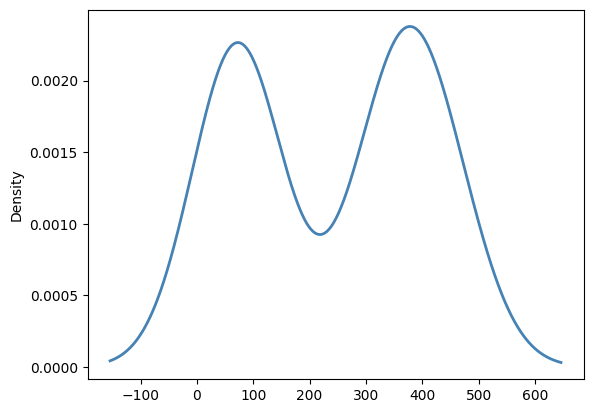

                                               nombre  energia_kcal
1886                  SOPA CONDENSADA, ENLAT. CEBOLLA            46
1946           SOPA CONDENSADA, ENLAT. POLLO C/FIDEOS            48
1997  SOPA CONDENSADA, ENLAT. VEGETALES (VEGETARIANA)            59
1996        SOPA CONDENSADA, ENLAT. POLLO C/VEGETALES            61
1891          SOPA CONDENSADA, ENLAT. VEGETALES Y RES            63
1890                   SOPA CONDENSADA, ENLAT. TOMATE            66
1889             SOPA CONDENSADA, ENLAT. RES C/FIDEOS            67
1888               SOPA CONDENSADA, ENLAT. MINESTRONE            68
1947            SOPA CONDENSADA, ENLAT. POLLO C/ARROZ            68
1893         SOPA CREMA CONDENSADA, ENLAT. ESPARRAGOS            69
1948               SOPA CREMA CONDENSADA, ENLAT. PAPA            74
1894             SOPA CREMA CONDENSADA, ENLAT. HONGOS            79
1892            SOPA CREMA CONDENSADA, ENLAT. CEBOLLA            88
1895              SOPA CREMA CONDENSADA, ENLAT. 

codigo                                                      20083
nombre                     SOPA CONDENSADA, ENLAT. POLLO C/FIDEOS
energia_kcal                                                   48
agua_pct                                                       88
fraccion_comestible_pct                                      1.00
proteina_g                                                   2.37
grasa_total_g                                                1.55
ag_sat_g                                                     0.39
ag_mono_g                                                    0.54
ag_poli_g                                                    0.34
colesterol_mg                                                   8
carbohidratos_g                                              6.07
azucares_g                                                   0.00
ceniza_g                                                     0.90
fibra_dietetica_g                                            1.81
calcio_mg 

In [421]:
import matplotlib.pyplot as plt


def base_para_sopa_search():
    foodname = 'Bases para sopas'
    data = cba_products[foodname]
    keywords = data["keywords"]
    keywords += ['sopa', 'base']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('sopa', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['DESHIDRATADA', 'CONDENSADA']), case=False)]
    bases_sopas = filtered_table[~filtered_table['nombre'].str.contains('C/AGUA', case=False)]

    """ for i in list(bases_sopas['nombre']):
        print(i) """

    #print((bases_sopas[['nombre', 'energia_kcal']]))

    bases_sopas['energia_kcal'].plot(
    kind='kde',
    color='steelblue',
    linewidth=2
    )   
    plt.show()
    """
    Se evidencia que hay tienden a dos punto. En estos rangos: 0-200 y 200-600 

    Dado que nos interesa una base que se aproxime a las calorias indicadas por CBA (48KCal), 
    Vamos a tomar el primer grupo de datos. Con <200KCal
    
    """
    bases_sopas = bases_sopas[bases_sopas['energia_kcal']<200]

    print(bases_sopas[['nombre', 'energia_kcal']].sort_values(by='energia_kcal'))
    """
    nombre  energia_kcal
                  SOPA CONDENSADA, ENLAT. CEBOLLA            46
           SOPA CONDENSADA, ENLAT. POLLO C/FIDEOS            48
  SOPA CONDENSADA, ENLAT. VEGETALES (VEGETARIANA)            59
        SOPA CONDENSADA, ENLAT. POLLO C/VEGETALES            61
          SOPA CONDENSADA, ENLAT. VEGETALES Y RES            63
                   SOPA CONDENSADA, ENLAT. TOMATE            66
             SOPA CONDENSADA, ENLAT. RES C/FIDEOS            67
               SOPA CONDENSADA, ENLAT. MINESTRONE            68
            SOPA CONDENSADA, ENLAT. POLLO C/ARROZ            68
         SOPA CREMA CONDENSADA, ENLAT. ESPARRAGOS            69
               SOPA CREMA CONDENSADA, ENLAT. PAPA            74
             SOPA CREMA CONDENSADA, ENLAT. HONGOS            79
            SOPA CREMA CONDENSADA, ENLAT. CEBOLLA            88
              SOPA CREMA CONDENSADA, ENLAT. POLLO            90
             SOPA CONDENSADA, ENLAT. FRIJOL NEGRO            91
         SOPA CONDENSADA, ENLAT. FRIJOL CON CERDO           129
    """
    bases_sopas = bases_sopas[bases_sopas['nombre'] == 'SOPA CONDENSADA, ENLAT. POLLO C/FIDEOS']
    cba_products[foodname]["nutrition"] = bases_sopas.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


base_para_sopa_search()    
foodname = 'Bases para sopas'
cba_products[foodname]["nutrition"]

### Café instantáneo

In [422]:
def cafe_inst_search():
    foodname = 'Café instantáneo'
    data = cba_products[foodname]
    keywords = data["keywords"]
    keywords += ['cafe', 'instantaneo'] 

    cba_product: Product = cbadata.get_product(foodname)
    #print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table: pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='17']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[~filtered_table['nombre'].str.contains('cafeina', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['cafe', 'café']), case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']])
    # Filtrado hasta que quede una sola fila. 
    
    filtered_table = filtered_table[filtered_table['nombre'] == 'CAFE INSTANTANEO, POLVO']
    #print(filtered_table[['nombre', 'energia_kcal']])


    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


cafe_inst_search()    
foodname = 'Café instantáneo'
cba_products[foodname]["nutrition"]


codigo                                       17041
nombre                     CAFE INSTANTANEO, POLVO
energia_kcal                                   353
agua_pct                                         3
fraccion_comestible_pct                       1.00
proteina_g                                   12.20
grasa_total_g                                 0.50
ag_sat_g                                      0.20
ag_mono_g                                     0.04
ag_poli_g                                     0.20
colesterol_mg                                    0
carbohidratos_g                              75.40
azucares_g                                    0.00
ceniza_g                                      0.00
fibra_dietetica_g                             8.80
calcio_mg                                      141
hierro_mg                                     4.41
magnesio_mg                                    327
fosforo_mg                                     303
potasio_mg                     

### Café molido

In [423]:
# Café molido

def cafe_molido_search():
    foodname = 'Café molido'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    #print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']])

    filtered_table = filtered_table[filtered_table['nombre']=='CAFE TOSTADO MOLIDO, POLVO']
    # Filtrado hasta que quede una sola fila. 
    #print(filtered_table[['nombre', 'energia_kcal']])


    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


cafe_molido_search()    
foodname = 'Café molido'
cba_products[foodname]["nutrition"]


codigo                                          17039
nombre                     CAFE TOSTADO MOLIDO, POLVO
energia_kcal                                      226
agua_pct                                            5
fraccion_comestible_pct                          1.00
proteina_g                                      12.60
grasa_total_g                                   14.80
ag_sat_g                                          NaN
ag_mono_g                                         NaN
ag_poli_g                                         NaN
colesterol_mg                                     NaN
carbohidratos_g                                 63.40
azucares_g                                        NaN
ceniza_g                                         7.60
fibra_dietetica_g                                4.80
calcio_mg                                         148
hierro_mg                                        2.90
magnesio_mg                                       NaN
fosforo_mg                  

### Carne de pollo amarillo

In [424]:


def carne_de_pollo_blanco_search():
    foodname = 'Carne de pollo amarillo'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category'] == '3']
    
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pollo', case=False)]
    #filtered_table = filtered_table[filtered_table['nombre'].str.contains('amarillo', case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']])
    """
                                        nombre  energia_kcal
143             POLLO, ALAS C/PIEL, CRUDAS           191
144             POLLO, CARNE C/PIEL, CRUDA           215
145             POLLO, CARNE S/PIEL, CRUDA           119
146                  POLLO, CORAZON, CRUDO           153
147                   POLLO, HIGADO, CRUDO           119
148                 POLLO, HIGADO, HERVIDO           167
149                  POLLO, MOLLEJA, CRUDA            94
150                POLLO, MOLLEJA, HERVIDA           154
151           POLLO, CUADRIL C/PIEL, CRUDO           221
152           POLLO, CUADRIL S/PIEL, CRUDO           121
153           POLLO, PECHUGA C/PIEL, CRUDA           172
154            POLLO, PIERNA C/PIEL, CRUDA           214
155      POLLO, VISCERAS O MENUDOS, CRUDOS           168
156    POLLO, VISCERAS O MENUDOS, HERVIDOS           194
164                POLLO, CORAZON, HERVIDO           185
165  POLLO, PECHUGA S/PIEL, CRUDA (FILETE)           120
166             POLLO, MUSLO C/PIEL, CRUDO           161
167            POLLO, PIERNA S/PIEL, CRUDO           120


    En cuanto a Calorias y pieza generia la mas cercana es POLLO, MUSLO C/PIEL, CRUDO
    
    """
    
    
    # Filtrado hasta que quede una sola fila. 
    filtered_table = filtered_table[filtered_table['nombre'] == 'POLLO, MUSLO C/PIEL, CRUDO']
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


carne_de_pollo_blanco_search()    
foodname = 'Carne de pollo amarillo'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 148.23692869084607


codigo                                           3058
nombre                     POLLO, MUSLO C/PIEL, CRUDO
energia_kcal                                      161
agua_pct                                           72
fraccion_comestible_pct                          0.65
proteina_g                                      18.08
grasa_total_g                                    9.20
ag_sat_g                                         2.46
ag_mono_g                                        3.72
ag_poli_g                                        1.97
colesterol_mg                                      92
carbohidratos_g                                  0.11
azucares_g                                       0.00
ceniza_g                                         0.00
fibra_dietetica_g                                0.86
calcio_mg                                           8
hierro_mg                                        0.71
magnesio_mg                                        18
fosforo_mg                  

###  Carne de pollo blanco 


In [425]:
def carne_de_pollo_blanco_search():
    foodname = 'Carne de pollo blanco'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '3'] # Carne de Ave
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pollo', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    
    # Filtrado hasta que quede una sola fila. 
   
    #print(filtered_table[['nombre', 'energia_kcal']])
    
    filtered_table = filtered_table[filtered_table['nombre'] == 'POLLO, MUSLO C/PIEL, CRUDO']
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


carne_de_pollo_blanco_search()    
foodname = 'Carne de pollo blanco'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 148.23538569733674


codigo                                           3058
nombre                     POLLO, MUSLO C/PIEL, CRUDO
energia_kcal                                      161
agua_pct                                           72
fraccion_comestible_pct                          0.65
proteina_g                                      18.08
grasa_total_g                                    9.20
ag_sat_g                                         2.46
ag_mono_g                                        3.72
ag_poli_g                                        1.97
colesterol_mg                                      92
carbohidratos_g                                  0.11
azucares_g                                       0.00
ceniza_g                                         0.00
fibra_dietetica_g                                0.86
calcio_mg                                           8
hierro_mg                                        0.71
magnesio_mg                                        18
fosforo_mg                  

Se uso el mismo que el del pollo amarillo

### Carne de res con hueso para cocido

In [426]:


def carne_res_c_hueso_search():
    foodname = 'Carne de res con hueso para cocido'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table: pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '5']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]

    """
    Reducimos las opciones incluyendo cortes populares para cocido (de acuerdo a https://soymigrante.com/revista/recetas-chapinas-caldo-de-res-al-estilo-guatemalteco/)
    """

    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['bolovique', 'posta', 'costilla']), case=False)] 

    #print(filtered_table[['nombre', 'energia_kcal']])
    filtered_table = filtered_table[filtered_table['energia_kcal']<150]
    print(filtered_table[['codigo', 'nombre', 'energia_kcal']].sort_values('energia_kcal'))

    """
    El mas cercano en energia es bolovique
    RES, BOLOVIQUE/MANO DE PIEDRA, MAGRO, CRUDO           121
    """
    filtered_table = filtered_table[filtered_table['nombre']=='RES, BOLOVIQUE/MANO DE PIEDRA, MAGRO, CRUDO']

   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


carne_res_c_hueso_search()    
foodname = 'Carne de res con hueso para cocido'
cba_products[foodname]["nutrition"]




Energia indicada por CBA por 100g: 95.90589673082799
    codigo                                       nombre  energia_kcal
282   5062  RES, BOLOVIQUE/MANO DE PIEDRA, MAGRO, CRUDO           121
299   5079            RES, POSTA DE PECHO, MAGRA, CRUDA           132


codigo                                                            5062
nombre                     RES, BOLOVIQUE/MANO DE PIEDRA, MAGRO, CRUDO
energia_kcal                                                       121
agua_pct                                                            73
fraccion_comestible_pct                                           0.98
proteina_g                                                       23.37
grasa_total_g                                                     3.04
ag_sat_g                                                          1.09
ag_mono_g                                                         1.27
ag_poli_g                                                         0.23
colesterol_mg                                                       60
carbohidratos_g                                                   0.00
azucares_g                                                        0.00
ceniza_g                                                          0.00
fibra_

### Carne de res molida

In [427]:
def carne_de_res_molida_search():
    foodname = 'Carne de res molida'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    
    filtered_table: pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '5']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('res', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['molida', 'molido']), case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']])
    """
    Por energia la mas cerca es: 
 RES, CARNE MOLIDA, SEMIMAGRA (10% GRASA), CRUDA           176

    """
    filtered_table = filtered_table[filtered_table['nombre']=='RES, CARNE MOLIDA, SEMIMAGRA (10% GRASA), CRUDA']
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


carne_de_res_molida_search()    
foodname = 'Carne de res molida'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 178.45192489595158


codigo                                                                5072
nombre                     RES, CARNE MOLIDA, SEMIMAGRA (10% GRASA), CRUDA
energia_kcal                                                           176
agua_pct                                                                69
fraccion_comestible_pct                                               1.00
proteina_g                                                           20.00
grasa_total_g                                                        10.00
ag_sat_g                                                              3.93
ag_mono_g                                                             4.19
ag_poli_g                                                             0.35
colesterol_mg                                                           65
carbohidratos_g                                                       0.00
azucares_g                                                            0.00
ceniza_g                 

### Carne de res para asar (con y sin hueso)

In [428]:
def carne_de_res_asar_search():
    foodname = 'Carne de res para asar (con y sin hueso)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    
    filtered_table: pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '5']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['res', 'vaca', 'vacuno']), case=False)]
    # Filtrado hasta que quede una sola fila. 
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=True))

    """
    En nombre y energia el que mas coincide es 
    RES, LOMITO O FILETE, SEMIMAGRO, CRUDO           147

    """ 
    filtered_table = filtered_table[filtered_table['nombre']== 'RES, LOMITO O FILETE, SEMIMAGRO, CRUDO']

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


carne_de_res_asar_search()    
foodname = 'Carne de res para asar (con y sin hueso)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 147.558963760628


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\1116754189.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                                       5066
nombre                     RES, LOMITO O FILETE, SEMIMAGRO, CRUDO
energia_kcal                                                  147
agua_pct                                                       72
fraccion_comestible_pct                                      0.99
proteina_g                                                  21.72
grasa_total_g                                                6.67
ag_sat_g                                                     2.36
ag_mono_g                                                    2.58
ag_poli_g                                                    0.45
colesterol_mg                                                  61
carbohidratos_g                                              0.00
azucares_g                                                   0.00
ceniza_g                                                     0.00
fibra_dietetica_g                                            1.10
calcio_mg 

### Carne de res sin hueso (posta)

In [429]:
def cereales_bolsa_caja_search():
    foodname = 'Carne de res sin hueso (posta)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table: pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '5']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('posta', case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=True))
    """
    La mas coincidente en 
    300      RES, POSTA DE PECHO, SEMIMAGRA, CRUDA           165

    
    """
    # Filtrado hasta que quede una sola fila. 
    filtered_table = filtered_table[filtered_table['nombre']=='RES, POSTA DE PECHO, SEMIMAGRA, CRUDA']
    

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


cereales_bolsa_caja_search()    
foodname = 'Carne de res sin hueso (posta)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 165.6046827011288


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\89131982.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                                      5080
nombre                     RES, POSTA DE PECHO, SEMIMAGRA, CRUDA
energia_kcal                                                 165
agua_pct                                                      70
fraccion_comestible_pct                                     0.99
proteina_g                                                 20.32
grasa_total_g                                               9.29
ag_sat_g                                                    3.59
ag_mono_g                                                   4.59
ag_poli_g                                                   0.39
colesterol_mg                                                 67
carbohidratos_g                                             0.00
azucares_g                                                  0.00
ceniza_g                                                    0.00
fibra_dietetica_g                                           0.98
calcio_mg                

### Cebollas

In [430]:
def cereales_bolsa_caja_search():
    foodname = 'Cebollas'
    data = cba_products[foodname]
    keywords = data["keywords"]
    keywords += ['cebolla']


    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal'))

    """
                                                 nombre  energia_kcal
1919          SOPA DESHIDRATADA, CEBOLLA, PREP. C/AGUA,            12
1896      SOPA CONDENSADA, ENLAT. CEBOLLA, PREP. C/AGUA            23
605                                     CEBOLLA, TALLOS            27
776                          CEBOLLA, PICADA, CONGELADA            29
778                                     CEBOLLA, MORADA            32
606                            CEBOLLA, CABEZA Y TALLOS            32
604                                     CEBOLLA, CABEZA            40
1882                 SALSA, PROCESADA, TOMATE C/CEBOLLA            42
1902  SOPA CREMA CONDENSADA, ENLAT. CEBOLLA, PREP. C...            44
742                    CEBOLLA, COCIDA S/SAL, ESCURRIDA            44
1886                    SOPA CONDENSADA, ENLAT. CEBOLLA            46
1892              SOPA CREMA CONDENSADA, ENLAT. CEBOLLA            88
1906                         SOPA DESHIDRATADA, CEBOLLA           293
2188                                     CEBOLLA, POLVO           341
777                     CEBOLLA, DESHIDRATADA, HOJUELAS           349
2017                AROS DE CEBOLLA, EMPANIZADOS FRITOS           411
2259          CHIPS DE MAIZ EXTRUSADO, SABOR DE CEBOLLA           499
2275                            PAPALINAS SABOR CEBOLLA           531


    El mas cercano en descripcion y energia es 
     CEBOLLA, CABEZA            40
    """

    filtered_table = filtered_table[filtered_table['nombre']=='CEBOLLA, CABEZA']

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 



cereales_bolsa_caja_search()    
foodname = 'Cebollas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 36.90506645226523


codigo                               11036
nombre                     CEBOLLA, CABEZA
energia_kcal                            40
agua_pct                                89
fraccion_comestible_pct               0.91
proteina_g                            1.10
grasa_total_g                         0.10
ag_sat_g                              0.04
ag_mono_g                             0.01
ag_poli_g                             0.02
colesterol_mg                            0
carbohidratos_g                       9.34
azucares_g                            4.24
ceniza_g                              1.70
fibra_dietetica_g                     0.35
calcio_mg                               23
hierro_mg                             0.21
magnesio_mg                             10
fosforo_mg                              29
potasio_mg                             146
sodio_mg                                 4
zinc_mg                               0.17
cobre_mg                              0.04
selenio_mcg

### Cereales de bolsa o caja

In [431]:
def cereales_bolsa_caja_search():
    foodname = 'Cereales de bolsa o caja'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by="energia_kcal"))
    # Filtrado hasta que quede una sola fila. 
    """
    CEREAL DE DESAYUNO, GRANOLA, CEREALES ENTEROS ...           381
    """
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('CEREAL DE DESAYUNO, GRANOLA, CEREALES ENTEROS', case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by="energia_kcal"))

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


cereales_bolsa_caja_search()    
foodname = 'Cereales de bolsa o caja'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 361.8039157811885


codigo                                                                 13100
nombre                     CEREAL DE DESAYUNO, GRANOLA, CEREALES ENTEROS ...
energia_kcal                                                             381
agua_pct                                                                   6
fraccion_comestible_pct                                                 1.00
proteina_g                                                              7.90
grasa_total_g                                                           4.69
ag_sat_g                                                                0.89
ag_mono_g                                                               2.10
ag_poli_g                                                               1.39
colesterol_mg                                                              0
carbohidratos_g                                                        79.40
azucares_g                                                             31.89

### Chile pimiento fresco

In [432]:

def pimiento_fresco_search():
    foodname = 'Chile pimiento fresco'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='11']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pimiento', case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']])
    """
                                                nombre  energia_kcal
625            CHILE, DULCE/PIMIENTO, ROJO, FRESCO            31
626  CHILE, DULCE/PIMIENTO, ROJO, ENLATADO SOL&LIQ            18
627                   CHILE, DULCE/PIMIENTO, VERDE            20
    

El mas cercano en energia y nombre. 
  CHILE, DULCE/PIMIENTO, ROJO, FRESCO            31
    """

    filtered_table = filtered_table[filtered_table['nombre']=='CHILE, DULCE/PIMIENTO, ROJO, FRESCO']
    #print(filtered_table[['nombre', 'energia_kcal']])


    

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


pimiento_fresco_search()    
foodname = 'Chile pimiento fresco'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 25.696469878306345


codigo                                                   11058
nombre                     CHILE, DULCE/PIMIENTO, ROJO, FRESCO
energia_kcal                                                31
agua_pct                                                    92
fraccion_comestible_pct                                   0.82
proteina_g                                                0.99
grasa_total_g                                             0.30
ag_sat_g                                                  0.03
ag_mono_g                                                 0.00
ag_poli_g                                                 0.07
colesterol_mg                                                0
carbohidratos_g                                           6.03
azucares_g                                                4.20
ceniza_g                                                  2.10
fibra_dietetica_g                                         0.47
calcio_mg                                              

### Cilantro perejil y hierbabuena

In [433]:
def cilantro_perejil_hierbabuena_search():
    foodname = 'Cilantro perejil y hierbabuena'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']])
    """
                                    nombre  energia_kcal
657                HIERBABUENA, FRESCA            70
700                    PEREJIL, FRESCO            36
827           PEREJIL, SECO, CONGELADO           271
2189  CILANTRO O CULANTRO, HOJAS SECAS           279
2221                     PEREJIL, SECO           292
2224   SAZONADOR, C/CILANTRO Y ACHIOTE             0
2229       CILANTRO O CULANTRO, FRESCO            23

El mas cercano en energia:
 CILANTRO O CULANTRO, FRESCO            23
    """
    # Filtrado hasta que quede una sola fila. 
    filtered_table = filtered_table[filtered_table['nombre']=='CILANTRO O CULANTRO, FRESCO']
    print(filtered_table[['nombre', 'energia_kcal']])

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


cilantro_perejil_hierbabuena_search()    
foodname = 'Cilantro perejil y hierbabuena'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 18.40372523431012
                           nombre  energia_kcal
2229  CILANTRO O CULANTRO, FRESCO            23


codigo                                           22047
nombre                     CILANTRO O CULANTRO, FRESCO
energia_kcal                                        23
agua_pct                                            92
fraccion_comestible_pct                           0.85
proteina_g                                        2.13
grasa_total_g                                     0.52
ag_sat_g                                          0.01
ag_mono_g                                         0.28
ag_poli_g                                         0.04
colesterol_mg                                        0
carbohidratos_g                                   3.67
azucares_g                                        0.87
ceniza_g                                          2.80
fibra_dietetica_g                                 1.47
calcio_mg                                           67
hierro_mg                                         1.77
magnesio_mg                                         26
fosforo_mg

### Consomé

In [434]:
def consome_search():
    foodname = 'Consomé'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['consome']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    #filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'] == '']
    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False))
    
    """
                                                     nombre  energia_kcal
1969  CALDO/CONSOME DE RES, DESHIDR., BAJO SODIO, CU...           438
1874         CALDO/CONSOME DE POLLO, DESHIDR., EN POLVO           267
1876           CALDO/CONSOME DE RES, DESHIDR., EN POLVO           213
1873       CALDO/CONSOME DE POLLO, DESHIDR., EN CUBITOS           198
1875         CALDO/CONSOME DE RES, DESHIDR., EN CUBITOS           170
1965  CALDO/CONSOME DE POLLO, DESHIDR., EN CUBITOS, ...             5
1966  CALDO/CONSOME DE POLLO, DESHIDR., EN POLVO, PR...             4
1967  CALDO/CONSOME DE RES, DESHIDR., EN CUBITOS, PR...             3
1968  CALDO/CONSOME DE RES, DESHIDR., EN POLVO, PREP...             3


El mas cercano enm energia y descripcion es: 
1874         CALDO/CONSOME DE POLLO, DESHIDR., EN POLVO           267


    
    """
    filtered_table = filtered_table[filtered_table['nombre']=='CALDO/CONSOME DE POLLO, DESHIDR., EN POLVO']
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False))

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


consome_search()    
foodname = 'Consomé'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 271.0888525483784


codigo                                                          20011
nombre                     CALDO/CONSOME DE POLLO, DESHIDR., EN POLVO
energia_kcal                                                      267
agua_pct                                                            2
fraccion_comestible_pct                                          1.00
proteina_g                                                      16.66
grasa_total_g                                                   13.88
ag_sat_g                                                         3.43
ag_mono_g                                                        5.36
ag_poli_g                                                        4.48
colesterol_mg                                                      13
carbohidratos_g                                                 18.01
azucares_g                                                      17.36
ceniza_g                                                         0.00
fibra_dietetica_g   

### Crema artesanal 

In [435]:
def crema_artesanal_search():
    foodname = 'Crema artesanal'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    
    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='1']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('crema', case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False))
    """
                                                    nombre  energia_kcal
    2                 CREMA, SUSTITUTO NO LACTEO, EN POLVO           529
    88               LECHE DELACTOMY SEMIDESCREMADA, POLVO           475
    85                   LECHE DELACTOMY DESCREMADA, POLVO           370
    9                LECHE DESCREMADA, EN POLVO, S/VIT A&D           362
    10               LECHE DESCREMADA, EN POLVO, C/VIT A&D           362
    11   LECHE DESCREMADA, EN POLVO, INSTANTANEA, C/VIT...           358
    56                 LECHE DESCREMADA, EN POLVO (PL 480)           354
    20                              QUESO CREMA O DE CAPAS           350
    0                                        CREMA, ESPESA           340
    1                                          CREMA, RALA           292
    28          QUESO BLANCO, OREADO, LECHE SEMIDESCREMADA           263
    62                                    CREMA, CHANTILLI           257
    23           QUESO BLANCO FRESCO, LECHE SEMIDESCREMADA           254
    64                 CREMA, SUSTITUTO NO LACTEO, LIQUIDO           251
    29              QUESO BLANCO, OREADO, LECHE DESCREMADA           232
    ...


    El que mejor se acerca en nombre

    CREMA, ESPESA           340

    """
    filtered_table = filtered_table[filtered_table['nombre']=='CREMA, ESPESA']
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False))
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


crema_artesanal_search()    
foodname = 'Crema artesanal'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 344.9407924700167


codigo                              1001
nombre                     CREMA, ESPESA
energia_kcal                         340
agua_pct                              58
fraccion_comestible_pct             1.00
proteina_g                          2.84
grasa_total_g                      36.08
ag_sat_g                           23.03
ag_mono_g                           9.10
ag_poli_g                           1.57
colesterol_mg                        113
carbohidratos_g                     2.74
azucares_g                          2.92
ceniza_g                            0.00
fibra_dietetica_g                   0.53
calcio_mg                             66
hierro_mg                           0.10
magnesio_mg                            7
fosforo_mg                            58
potasio_mg                            95
sodio_mg                              27
zinc_mg                             0.24
cobre_mg                            0.01
selenio_mcg                         3.00
vitamina_c_mg   

### Crema industrializada

In [436]:
def crema_industrializada_search():
    foodname = 'Crema industrializada'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('crema', case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False))
    """
                                                    nombre  energia_kcal
2                 CREMA, SUSTITUTO NO LACTEO, EN POLVO           529
88               LECHE DELACTOMY SEMIDESCREMADA, POLVO           475
85                   LECHE DELACTOMY DESCREMADA, POLVO           370
9                LECHE DESCREMADA, EN POLVO, S/VIT A&D           362
10               LECHE DESCREMADA, EN POLVO, C/VIT A&D           362
11   LECHE DESCREMADA, EN POLVO, INSTANTANEA, C/VIT...           358
56                 LECHE DESCREMADA, EN POLVO (PL 480)           354
20                              QUESO CREMA O DE CAPAS           350
0                                        CREMA, ESPESA           340
1                                          CREMA, RALA           292
28          QUESO BLANCO, OREADO, LECHE SEMIDESCREMADA           263
62                                    CREMA, CHANTILLI           257
23           QUESO BLANCO FRESCO, LECHE SEMIDESCREMADA           254
64                 CREMA, SUSTITUTO NO LACTEO, LIQUIDO           251
29              QUESO BLANCO, OREADO, LECHE DESCREMADA           232
...


El que mejor se acerca en nombre

0                                        CREMA, ESPESA           340

    """
    filtered_table = filtered_table[filtered_table['nombre']=='CREMA, ESPESA']
    
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


crema_industrializada_search()    
foodname = 'Crema industrializada'
cba_products[foodname]["composition"]
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 344.79234205028456


codigo                              1001
nombre                     CREMA, ESPESA
energia_kcal                         340
agua_pct                              58
fraccion_comestible_pct             1.00
proteina_g                          2.84
grasa_total_g                      36.08
ag_sat_g                           23.03
ag_mono_g                           9.10
ag_poli_g                           1.57
colesterol_mg                        113
carbohidratos_g                     2.74
azucares_g                          2.92
ceniza_g                            0.00
fibra_dietetica_g                   0.53
calcio_mg                             66
hierro_mg                           0.10
magnesio_mg                            7
fosforo_mg                            58
potasio_mg                            95
sodio_mg                              27
zinc_mg                             0.24
cobre_mg                            0.01
selenio_mcg                         3.00
vitamina_c_mg   

Se uso el mismo que para la artesanal 

### Desayuno o cena continental (bebida y dos acompañamientos elaborados)

No se encontró el "Desayuno o cena continental" en la tabla de composicion de alimentos del INCAP, de manera que alternativamente se buscara reconstruir el alimento parte por parte y buscando encaje energeticamente con  

Construccion de desayuno continental 

Tomamos la descripcion de 
https://www.cafeamericano.com/newsroom/continental-breakfast/


1. Bread Items (Pan/Bollería)
    - Pan blanco o integral tostado
    - English muffins
    - Donuts
    - Croissants
    - Danish pastry
    Acompañados de: jam, butter, jelly, honey, marmalade

2. Beverages (Bebida)
    - Té, café, chocolate caliente
    - Leche
    - Jugos: mango, naranja, piña, toronja

3. Fresh Fruits (Fruta fresca)
    - Banano, manzana, naranja, toronja
    - Servida entera o como cóctel de frutas


Y los detallaes en el nombre indicado por la CBA: 
Bebida y dos acompañamientos elaborados

Entonces lo interpretamos de la siguiente forma: 

- Bebida: 
    - Jugo 
    - Café 
    - Té 
- Acompañamiento 1: 
    - Cossiant, Pan o bollería con su untable (jam, mantequilla, miel) (se considera uno solo porque el untable va sobre el pan, no es independiente)
- Acompañamiento 2
    - Fruta fresca


In [437]:
def desayuno_cena_search():
    foodname = 'Desayuno o cena continental (bebida y dos acompañamientos elaborados)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    """ filtered_table: pd.DataFrame = composition_table_food_df[
        composition_table_food_df['category'].isin(['24', '21'])
    ] """
    """ energy_tolerance = 0.2 # Numero de 0 a 1
    filtered_table = composition_table_food_df[
    (composition_table_food_df['energia_kcal'] < cba_product.kcal_per100_gram * (1+energy_tolerance)) &
    (composition_table_food_df['energia_kcal'] > cba_product.kcal_per100_gram * (1-energy_tolerance))
    ]   """ 
    
    # Vemos que alimentos nos dan cercanos a la energia indicada por el CBA

    # No se encontraron opciones viables. 
    # Se procede con la construccion del desyuno continental 
    #filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['desayuno', 'cena']), case=False)] # Sin resultados
    
    #print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal', ascending=False))

    """
    Acompañamiento 1: Pan o bollería con su untable (jam, mantequilla, miel) — se considera uno solo porque el untable va sobre el pan, no es independiente
    """

    filtered_table_bollo = composition_table_food_df[composition_table_food_df['nombre'].str.contains('bollo', case=False)]


     
    #print(filtered_table_bollo[['codigo','nombre', 'energia_kcal']].sort_values(by='energia_kcal'))
    """
                                              nombre  energia_kcal
2071               BOLLO C/HUEVO, QUESO Y TOCINO           228
2009                       BOLLO C/HUEVO Y JAMON           233 >> Este ya incluye el untable y 
2605                          BOLLOS, SIN GLUTEN           257
1274                   BOLLOS DE TRIGO, INTEGRAL           266
1277                     BOLLOS DE TRIGO, BLANCO           273
2008                               BOLLO C/HUEVO           274
1243                    PAN INTEGRAL, TIPO BOLLO           278
1237              PAN BLANCO, TIPO BOLLO C/LECHE           285
2070            BOLLO C/HUEVO, QUESO Y SALCHICHA           286
1275                           BOLLOS DE CENTENO           286
2050                      BOLLO C/HUEVO Y TOCINO           305
1276        BOLLOS DE HUEVO - “EGGS TWIST BREAD”           307
2656  BOLLOS, SIN GLUTEN (ARROZ, TAPIOCA Y PAPA)           310
2072                   BOLLO C/QUESO Y SALCHICHA           338
2051                               BOLLO C/JAMON           342
2052                           BOLLO C/SALCHICHA           371
    """
    filtered_table_bollo = filtered_table_bollo[filtered_table_bollo['nombre'].str.contains('Y JAMON')]
    #print(filtered_table_bollo[['nombre', 'energia_kcal']])
    aporte_energetico_total = 0

    parte_de_porcion_bollo = 0.5 # 50%
    aporte_energetico_bollo = float(filtered_table_bollo.iloc[-1].get('energia_kcal')) * parte_de_porcion_bollo
    print(f"Aporte energetico bollo: {aporte_energetico_bollo} siendo el {parte_de_porcion_bollo*100}% del plato")
    aporte_energetico_total += aporte_energetico_bollo
    filtered_table_bollo[['nombre', 'energia_kcal']]


    #cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    """
    Acompañamiento 2: Fruta fresca
    """
    filtered_table_fruta = composition_table_food_df[composition_table_food_df['nombre'].str.contains('fruta', case=False)]
    #print(filtered_table_fruta[['category', 'nombre', 'energia_kcal']])
    filtered_table_fruta = filtered_table_fruta[filtered_table_fruta['category']=='12']
    filtered_table_fruta = filtered_table_fruta[filtered_table_fruta['nombre']=='FRUTAS MIXTAS, EN ALMIBAR, ENVASADAS SOL&LIQ']
    #print(filtered_table_fruta[['category', 'nombre', 'energia_kcal']])

    parte_de_porcion_fruta = 0.4 # 40%
    aporte_energetico_fruta = float(filtered_table_fruta.iloc[-1].get('energia_kcal')) * parte_de_porcion_fruta
    print(f"Aporte energetico frutas: {aporte_energetico_fruta} siendo el {parte_de_porcion_fruta*100}% del plato")
    aporte_energetico_total += aporte_energetico_fruta
    filtered_table_bollo[['nombre', 'energia_kcal']]


    """
    Bebida: Jugo de naranja
    """
    filtered_table_jugo_naranja = composition_table_food_df[composition_table_food_df['category']=='17']
    filtered_table_jugo_naranja = filtered_table_jugo_naranja[filtered_table_jugo_naranja['nombre'].str.contains('jugo', case=False)]
    filtered_table_jugo_naranja = filtered_table_jugo_naranja[filtered_table_jugo_naranja['nombre'].str.contains('naranja', case=False)]
    filtered_table_jugo_naranja = filtered_table_jugo_naranja[filtered_table_jugo_naranja['nombre']=='BEBIDA, JUGO NARANJA, S/PULPA, S/AZUCAR']

    #print(filtered_table_jugo_naranja[['nombre', 'energia_kcal']])


    parte_de_porcion_jugo = 0.1 # 10%
    aporte_energetico_jugo = float(filtered_table_jugo_naranja.iloc[-1].get('energia_kcal')) * parte_de_porcion_jugo
    print(f"Aporte energetico frutas: {aporte_energetico_jugo} siendo el {parte_de_porcion_jugo*100}% del plato")
    aporte_energetico_total += aporte_energetico_jugo

    print(f"Aporte energetico objetivo: {cba_product.kcal_per100_gram}")
    print(f"Aporte energetico alcanzado: {aporte_energetico_total}")
    print(f"%error energetico: {(100*abs(aporte_energetico_total-cba_product.kcal_per100_gram)/(cba_product.kcal_per100_gram)):.2f}%")


    cba_products[foodname]["nutrition"] = pd.concat([
        filtered_table_bollo,
        filtered_table_fruta,
        filtered_table_jugo_naranja
    ]).reset_index(drop=True)

    cba_products[foodname]["composition"] = {
        str(filtered_table_bollo.iloc[-1].get('codigo')): {"portion": parte_de_porcion_bollo},
        str(filtered_table_fruta.iloc[-1].get('codigo')): {"portion": parte_de_porcion_fruta},
        str(filtered_table_jugo_naranja.iloc[-1].get('codigo')): {"portion": parte_de_porcion_jugo},
    }


desayuno_cena_search()    
foodname = 'Desayuno o cena continental (bebida y dos acompañamientos elaborados)'
cba_products[foodname]["nutrition"]
cba_products[foodname]["composition"]



Energia indicada por CBA por 100g: 124.01526740648552
Aporte energetico bollo: 116.5 siendo el 50.0% del plato
Aporte energetico frutas: 22.8 siendo el 40.0% del plato
Aporte energetico frutas: 2.1 siendo el 10.0% del plato
Aporte energetico objetivo: 124.01526740648552
Aporte energetico alcanzado: 141.4
%error energetico: 14.02%


{'21002': {'portion': 0.5},
 '12044': {'portion': 0.4},
 '17136': {'portion': 0.1}}

### Dulces en general (incluye paletas bombones gomitas)

In [438]:
def dulce_general_search():
    foodname = 'Dulces en general (incluye paletas bombones gomitas)'
    data = cba_products[foodname]
    keywords = data["keywords"]+['paleta', 'gomita', 'bombon', 'dulce']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    
    filtered_table: pd.DataFrame  = composition_table_food_df[composition_table_food_df['category']=='15']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values(by='energia_kcal'))
    mediana = filtered_table['energia_kcal'].median()
    print(f"Mediana de energía: {mediana:.2f} kcal")
    # Filtrado hasta que quede una sola fila. 
    media = filtered_table['energia_kcal'].mean()
    print(f"Media de energía: {media:.2f} kcal")

    """
    Hace referencia al grupo mas amplio asi que hacemos la seleccion segun el mas representativo de acuerdo a mediana y media en energia.  

    DULCES, CHICLOSOS (FRUIT CHEWS)           400

    Es la mediana y es el registro mas cercano a la media. 
    """
    filtered_table = filtered_table[filtered_table['nombre']=='DULCES, CHICLOSOS (FRUIT CHEWS)']

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 
    


dulce_general_search()    
foodname = 'Dulces en general (incluye paletas bombones gomitas)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 397.60348583878
                                                 nombre  energia_kcal
1351              DULCE DE NANCE, CON ALMIBAR, ENLATADO            95
1352                                    DULCE DE PAPAYA           221
1368           DULCES, GOMA DE MASCAR (CHICLE) S/AZUCAR           268
1350                          AREQUIPE O DULCE DE LECHE           315
1341                     DULCES, ANGELES O MARSHMELLOWS           318
1406         DULCES, CONFITE, SUAVE, (GOMITAS) S/AZUCAR           354
1377                        COCO, CREMA DULCE, ENLATADA           357
1349                                   DULCE DE GUAYABA           357
1344           DULCES, GOMA DE MASCAR (CHICLE) C/AZUCAR           360
1384                                 DULCE DE TAMARINDO           368
1385              DULCES, GRAGEAS DE JALEA (JELLYBEANS)           375
1354                                    DULCE DE ZAPOTE           393
1342                              DULCE

C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\608536023.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                               15062
nombre                     DULCES, CHICLOSOS (FRUIT CHEWS)
energia_kcal                                           400
agua_pct                                                11
fraccion_comestible_pct                               1.00
proteina_g                                            0.39
grasa_total_g                                         7.78
ag_sat_g                                              7.52
ag_mono_g                                              NaN
ag_poli_g                                              NaN
colesterol_mg                                            0
carbohidratos_g                                      79.73
azucares_g                                           56.10
ceniza_g                                              0.00
fibra_dietetica_g                                     0.30
calcio_mg                                                0
hierro_mg                                             0.

### Espagueti

In [439]:
def espagueti_search():
    foodname = 'Espagueti'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    #filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'].isin(['13', '24'])]
    filtered_table  = composition_table_food_df

    #filtered_table  = filtered_table[~filtered_table['nombre'].str.contains('arroz', case=False)]
    #filtered_table  = filtered_table[~filtered_table['nombre'].str.contains('avena', case=False)]
    """
    El espagueti (del italiano spaghetti [spagetti]; en singular, spaghetto) es un tipo de pasta italiana elaborada con harina de grano duro y agua.
    """
    filtered_table  = filtered_table[filtered_table['nombre'].str.contains('pasta', case=False)]
    filtered_table = filtered_table[
    (filtered_table['energia_kcal'] < 400) &
    (filtered_table['energia_kcal'] > 300)
    ]
    filtered_table  = filtered_table[filtered_table['nombre']=='PASTA S/ENRIQUECER, CRUDA']
    #filtered_table  = filtered_table[filtered_table['nombre'].str.contains('fideo', case=False)]
    #filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['category', 'nombre', 'energia_kcal']].sort_values(by='energia_kcal'))
    
    # Filtrado hasta que quede una sola fila. 
    

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


espagueti_search()    
foodname = 'Espagueti'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 376.2120101034792
     category                     nombre  energia_kcal
1103       13  PASTA S/ENRIQUECER, CRUDA           371


codigo                                         13057
nombre                     PASTA S/ENRIQUECER, CRUDA
energia_kcal                                     371
agua_pct                                          10
fraccion_comestible_pct                         1.00
proteina_g                                     13.04
grasa_total_g                                   1.51
ag_sat_g                                        0.28
ag_mono_g                                       0.17
ag_poli_g                                       0.56
colesterol_mg                                      0
carbohidratos_g                                74.67
azucares_g                                      2.67
ceniza_g                                        3.20
fibra_dietetica_g                               0.88
calcio_mg                                         21
hierro_mg                                       1.30
magnesio_mg                                       53
fosforo_mg                                    

### Fideos en todas sus formas (Excepto macarrones y espagueti)

In [440]:
def frijoles_negros_secos_search():
    foodname = 'Fideos en todas sus formas (Excepto macarrones y espagueti)'
    data = cba_products[foodname] 
    keywords =  ['fideo', 'pasta']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[
        (filtered_table['energia_kcal'] < 400) &
        (filtered_table['energia_kcal'] > 300)
        ]
    filtered_table  = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table  = filtered_table[filtered_table['nombre']=='PASTA C/HUEVO S/ENRIQUECER, CRUDA']
    print(filtered_table[['nombre', 'energia_kcal']])

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


frijoles_negros_secos_search()    
foodname = 'Fideos en todas sus formas (Excepto macarrones y espagueti)'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 389.35408965974796
                                 nombre  energia_kcal
1111  PASTA C/HUEVO S/ENRIQUECER, CRUDA           384


codigo                                                 13065
nombre                     PASTA C/HUEVO S/ENRIQUECER, CRUDA
energia_kcal                                             384
agua_pct                                                   9
fraccion_comestible_pct                                 1.00
proteina_g                                             14.16
grasa_total_g                                           4.44
ag_sat_g                                                1.18
ag_mono_g                                               1.25
ag_poli_g                                               1.33
colesterol_mg                                             84
carbohidratos_g                                        71.27
azucares_g                                              1.88
ceniza_g                                                3.30
fibra_dietetica_g                                       1.12
calcio_mg                                                 35
hierro_mg               

### Frijoles negros secos

In [441]:
def frijoles_negros_secos_search():
    foodname = 'Frijoles negros secos'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['frijol']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('frijol', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('negro', case=False)]

    #print(filtered_table[['nombre', 'energia_kcal']])
    filtered_table = filtered_table[filtered_table['nombre']=='FRIJOL NEGRO, GRANO SECO']
    print(filtered_table[['nombre', 'energia_kcal']])
    
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


frijoles_negros_secos_search()    
foodname = 'Frijoles negros secos'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 345.7239064951724
                       nombre  energia_kcal
470  FRIJOL NEGRO, GRANO SECO           341


codigo                                         9009
nombre                     FRIJOL NEGRO, GRANO SECO
energia_kcal                                    341
agua_pct                                         11
fraccion_comestible_pct                        1.00
proteina_g                                    21.60
grasa_total_g                                  1.42
ag_sat_g                                       0.37
ag_mono_g                                      0.12
ag_poli_g                                      0.61
colesterol_mg                                     0
carbohidratos_g                               62.36
azucares_g                                     2.12
ceniza_g                                      15.50
fibra_dietetica_g                              3.60
calcio_mg                                       123
hierro_mg                                      5.02
magnesio_mg                                     171
fosforo_mg                                      352
potasio_mg  

### Frijoles preparados procesados y condimentados (enlatados o empaquetados)

In [442]:
def frijoles_preparados_search():
    foodname = 'Frijoles preparados procesados y condimentados (enlatados o empaquetados)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    #filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table  = composition_table_food_df[composition_table_food_df['nombre'].str.contains('frijol', case=False)]
    filtered_table  = filtered_table[filtered_table['nombre'].str.contains('lata', case=False)]
    filtered_table  = filtered_table[filtered_table['nombre']=='FRIJOL ROJO, VOLTEADO, ENLATADO']
    #filtered_table  = filtered_table[filtered_table['nombre'].str.contains('', case=False)]
    print(filtered_table[['nombre', 'energia_kcal']])
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


frijoles_preparados_search()    
foodname = 'Frijoles preparados procesados y condimentados (enlatados o empaquetados)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 169.28858094805392
                              nombre  energia_kcal
513  FRIJOL ROJO, VOLTEADO, ENLATADO           144


codigo                                                9057
nombre                     FRIJOL ROJO, VOLTEADO, ENLATADO
energia_kcal                                           144
agua_pct                                                71
fraccion_comestible_pct                               1.00
proteina_g                                            5.00
grasa_total_g                                         6.93
ag_sat_g                                              0.93
ag_mono_g                                             1.68
ag_poli_g                                             4.38
colesterol_mg                                          NaN
carbohidratos_g                                      15.47
azucares_g                                             NaN
ceniza_g                                              4.70
fibra_dietetica_g                                     1.89
calcio_mg                                               33
hierro_mg                                             1.

### Galletas dulces

In [443]:
def galletas_dulces_search():
    foodname = 'Galletas dulces'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='14']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('galleta', case=False)]
    filtered_table = filtered_table[filtered_table['energia_kcal']>420]
    filtered_table = filtered_table[filtered_table['nombre']== 'GALLETAS DULCES, SIMPLES C/RELLENO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


galletas_dulces_search()    
foodname = 'Galletas dulces'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 478.498663994656
                                  nombre  energia_kcal
1222  GALLETAS DULCES, SIMPLES C/RELLENO           483


codigo                                                  14003
nombre                     GALLETAS DULCES, SIMPLES C/RELLENO
energia_kcal                                              483
agua_pct                                                    2
fraccion_comestible_pct                                  1.00
proteina_g                                               4.50
grasa_total_g                                           20.00
ag_sat_g                                                 2.98
ag_mono_g                                                8.44
ag_poli_g                                                7.55
colesterol_mg                                               0
carbohidratos_g                                         72.10
azucares_g                                              39.30
ceniza_g                                                 1.50
fibra_dietetica_g                                        1.20
calcio_mg                                                  27
hierro_m

### Gasesosas

In [444]:
def gaseosas_search():
    foodname = 'Gaseosas'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['gaseosa']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA']
    print(filtered_table[['nombre', 'energia_kcal']])
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


gaseosas_search()    
foodname = 'Gaseosas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 37.511911273482845
                                      nombre  energia_kcal
1482  BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA            37


codigo                                                      17017
nombre                     BEBIDA, GASEOSA, TIPO COLAS, C/CAFEINA
energia_kcal                                                   37
agua_pct                                                       90
fraccion_comestible_pct                                      1.00
proteina_g                                                   0.07
grasa_total_g                                                0.02
ag_sat_g                                                     0.00
ag_mono_g                                                    0.00
ag_poli_g                                                    0.00
colesterol_mg                                                   0
carbohidratos_g                                              9.56
azucares_g                                                   8.97
ceniza_g                                                     0.00
fibra_dietetica_g                                            0.04
calcio_mg 

### Güisquil

In [445]:
def guisquil_search():
    foodname = 'Güisquil'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['guisquil']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table  = filtered_table[filtered_table['nombre']=='CHAYOTE/GUISQUIL/PATASTE, CRUDO']
    print(filtered_table[['nombre', 'energia_kcal']])

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


guisquil_search()    
foodname = 'Güisquil'
#cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 14.821745537358922
                              nombre  energia_kcal
614  CHAYOTE/GUISQUIL/PATASTE, CRUDO            19


### Harina de maíz

In [446]:
def harina_de_maiz_search():
    foodname = 'Harina de maíz'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('harina', case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='HARINA DE MAIZ BLANCO, GRANO ENTERO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


harina_de_maiz_search()    
foodname = 'Harina de maíz'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 366.02996856693824
                                   nombre  energia_kcal
1079  HARINA DE MAIZ BLANCO, GRANO ENTERO           361


codigo                                                   13032
nombre                     HARINA DE MAIZ BLANCO, GRANO ENTERO
energia_kcal                                               361
agua_pct                                                    11
fraccion_comestible_pct                                   1.00
proteina_g                                                6.93
grasa_total_g                                             3.86
ag_sat_g                                                  0.54
ag_mono_g                                                 1.02
ag_poli_g                                                 1.76
colesterol_mg                                                0
carbohidratos_g                                          76.85
azucares_g                                                0.64
ceniza_g                                                  7.30
fibra_dietetica_g                                         1.45
calcio_mg                                              

### Harina para atoles (incluye Incaparina)

In [447]:
def harina_atoles__search():
    foodname = 'Harina para atoles (incluye Incaparina)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'].isin(['17', '25'])] #"25": "ALIMENTOS ESPECIALES" # "17": "BEBIDAS DIVERSAS"
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['harina', 'atol', 'incaparina']), case=False)] #"25": "ALIMENTOS ESPECIALES" # "17": "BEBIDAS DIVERSAS"
    filtered_table = filtered_table[filtered_table['nombre'].str.startswith('BEBIDA')] #"25": "ALIMENTOS ESPECIALES" # "17": "BEBIDAS DIVERSAS"
    filtered_table = filtered_table[filtered_table['energia_kcal']>300] #"25": "ALIMENTOS ESPECIALES" # "17": "BEBIDAS DIVERSAS"
    filtered_table = filtered_table[filtered_table['nombre']=='BEBIDA, INCAPARINA, ORIGINAL, POLVO'] #"25": "ALIMENTOS ESPECIALES" # "17": "BEBIDAS DIVERSAS"
    print(filtered_table[['category', 'nombre', 'energia_kcal']])
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


harina_atoles__search()    
foodname = 'Harina para atoles (incluye Incaparina)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 378.1931910423531
     category                               nombre  energia_kcal
2591       25  BEBIDA, INCAPARINA, ORIGINAL, POLVO           373


codigo                                                   25008
nombre                     BEBIDA, INCAPARINA, ORIGINAL, POLVO
energia_kcal                                               373
agua_pct                                                   NaN
fraccion_comestible_pct                                   1.00
proteina_g                                               21.33
grasa_total_g                                             5.33
ag_sat_g                                                  0.00
ag_mono_g                                                  NaN
ag_poli_g                                                  NaN
colesterol_mg                                                0
carbohidratos_g                                          64.00
azucares_g                                                 NaN
ceniza_g                                                 10.67
fibra_dietetica_g                                          NaN
calcio_mg                                              

### Huevos de gallina de granja

In [448]:
def huevos_search():
    foodname = 'Huevos de gallina de granja'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='2']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='HUEVO DE GALLINA, ENTERO, CRUDO']
    print(filtered_table[['nombre', 'energia_kcal']])   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


huevos_search()    
foodname = 'Huevos de gallina de granja'
#cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 127.58043985084643
                              nombre  energia_kcal
124  HUEVO DE GALLINA, ENTERO, CRUDO           143


### Jamón (pollo res cerdo mixto etc.)

In [449]:
def jamon_search():
    foodname = 'Jamón (pollo res cerdo mixto etc.)'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['jamon']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='7']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='JAMON AHUMADO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


jamon_search()    
foodname = 'Jamón (pollo res cerdo mixto etc.)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 123.868778280543
            nombre  energia_kcal
360  JAMON AHUMADO           122


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\1133029050.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                              7041
nombre                     JAMON AHUMADO
energia_kcal                         122
agua_pct                              70
fraccion_comestible_pct             1.00
proteina_g                         17.93
grasa_total_g                       2.37
ag_sat_g                            0.87
ag_mono_g                           1.24
ag_poli_g                           0.23
colesterol_mg                         22
carbohidratos_g                     7.27
azucares_g                          0.00
ceniza_g                            0.00
fibra_dietetica_g                   2.49
calcio_mg                              6
hierro_mg                           0.39
magnesio_mg                            8
fosforo_mg                           384
potasio_mg                           165
sodio_mg                             900
zinc_mg                             0.91
cobre_mg                            0.04
selenio_mcg                        10.40
vitamina_c_mg   

### Jugos de frutas en polvo

In [450]:
def jugo_fruta_polvo_search():
    foodname = 'Jugos de frutas en polvo'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'].isin(['12', '17'])]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['polvo']), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='BEBIDA, SABOR A FRUTAS, C/VIT C, POLVO']
    print(filtered_table[['category','nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


jugo_fruta_polvo_search()    
foodname = 'Jugos de frutas en polvo'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 222.40143369175627
     category                                  nombre  energia_kcal
1493       17  BEBIDA, SABOR A FRUTAS, C/VIT C, POLVO           218


codigo                                                      17032
nombre                     BEBIDA, SABOR A FRUTAS, C/VIT C, POLVO
energia_kcal                                                  218
agua_pct                                                        2
fraccion_comestible_pct                                      1.00
proteina_g                                                   0.45
grasa_total_g                                                0.04
ag_sat_g                                                     0.00
ag_mono_g                                                    0.00
ag_poli_g                                                    0.00
colesterol_mg                                                   0
carbohidratos_g                                             87.38
azucares_g                                                   0.00
ceniza_g                                                     0.10
fibra_dietetica_g                                           10.30
calcio_mg 

### Jugos de frutas líquidos

In [451]:
def jugo_fruta_liquido_search():
    foodname = 'Jugos de frutas líquidos'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category'].isin(['12', '17'])]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['fruta']), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='BEBIDA, JUGO DE FRUTAS Y VEGETALES, C/VIT A, C, E']

    print(filtered_table[['category','nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


jugo_fruta_liquido_search()    
foodname = 'Jugos de frutas líquidos'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 46.64127812377266
     category                                             nombre  energia_kcal
1584       17  BEBIDA, JUGO DE FRUTAS Y VEGETALES, C/VIT A, C, E            46


codigo                                                                 17135
nombre                     BEBIDA, JUGO DE FRUTAS Y VEGETALES, C/VIT A, C, E
energia_kcal                                                              46
agua_pct                                                                  88
fraccion_comestible_pct                                                 1.00
proteina_g                                                              0.30
grasa_total_g                                                           0.01
ag_sat_g                                                                0.00
ag_mono_g                                                               0.00
ag_poli_g                                                               0.00
colesterol_mg                                                              0
carbohidratos_g                                                        11.15
azucares_g                                                             10.37

### Leche en polvo

In [452]:
def leche_en_polvo_search():
    foodname = 'Leche en polvo'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    #filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['energia_kcal']>480]

    filtered_table = filtered_table[filtered_table['nombre']=='LECHE INTEGRA, EN POLVO, C/VIT D']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


leche_en_polvo_search()    
foodname = 'Leche en polvo'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 502.92047326643706
                              nombre  energia_kcal
14  LECHE INTEGRA, EN POLVO, C/VIT D           496


codigo                                                 1016
nombre                     LECHE INTEGRA, EN POLVO, C/VIT D
energia_kcal                                            496
agua_pct                                                  2
fraccion_comestible_pct                                1.00
proteina_g                                            26.32
grasa_total_g                                         26.71
ag_sat_g                                              16.74
ag_mono_g                                              7.92
ag_poli_g                                              0.67
colesterol_mg                                            97
carbohidratos_g                                       38.42
azucares_g                                            38.42
ceniza_g                                               0.00
fibra_dietetica_g                                      6.08
calcio_mg                                               912
hierro_mg                               

### Leche entera líquida industrializada

In [453]:
def leche_liquida_search():
    foodname = 'Leche entera líquida industrializada'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='1']
    filtered_table = filtered_table[filtered_table['energia_kcal']<100]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal')) #LECHE INTEGRA (3,25% GRASA), FLUIDA, C/VIT D
    filtered_table = filtered_table[filtered_table['nombre'].str.startswith('LECHE')]
    filtered_table = filtered_table[filtered_table['nombre']=='LECHE INTEGRA (3,25% GRASA), FLUIDA, C/VIT D']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal')) #LECHE INTEGRA (3,25% GRASA), FLUIDA, C/VIT D
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


leche_liquida_search()    
foodname = 'Leche entera líquida industrializada'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 61.81052835300948
                                                nombre  energia_kcal
53                                SUERO ACIDO DE LECHE            24
54                                SUERO DULCE DE LECHE            27
74   LECHE DE SOYA, DIF. SABORES, DESCREMADA, FORTI...            28
79   LECHE DE SOYA, ORIGINAL, FORTIFICADA, SEMIDESC...            30
75   LECHE DE SOYA, DIF. SABORES, FORTIFICADA, S/AZ...            33
78     LECHE DE SOYA, ORIGINAL, FORTIFICADA, S/AZUCAR,            34
89                 LECHE DESCREMADA, FLUIDA, C/VIT A&D            34
90                 LECHE DESCREMADA, FLUIDA, S/VIT A&D            34
84                  LECHE DELACTOMY DESCREMADA, FLUIDA            34
92    LECHE DESLACTOSADA, BAJA EN GRASA (LALA), FLUIDA            34
39   LECHE SEMIDESCREMADA (1% GRASA), FLUIDA, C/ VI...            42
77                LECHE DE SOYA, ORIGINAL, FORTIFICADA            43
76   LECHE DE SOYA, DIF. SABORES, SEMIDESCREMADA, 

codigo                                                             1015
nombre                     LECHE INTEGRA (3,25% GRASA), FLUIDA, C/VIT D
energia_kcal                                                         61
agua_pct                                                             88
fraccion_comestible_pct                                            1.00
proteina_g                                                         3.15
grasa_total_g                                                      3.25
ag_sat_g                                                           1.87
ag_mono_g                                                          0.81
ag_poli_g                                                          0.20
colesterol_mg                                                        10
carbohidratos_g                                                    4.80
azucares_g                                                         5.05
ceniza_g                                                        

### Lechuga achicoria y rugula fresca o refrigerada

In [454]:
def lechuga_achicoria_search():
    foodname = 'Lechuga achicoria y rugula fresca o refrigerada'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['lechuga']), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.startswith('LECHUGA')]
    filtered_table = filtered_table[filtered_table['nombre']=='LECHUGA NO ARREPOLLADA (BUTTERHEAD)']
    print(filtered_table[['nombre', 'energia_kcal']])
  
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


lechuga_achicoria_search()    
foodname = 'Lechuga achicoria y rugula fresca o refrigerad'
#cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 13.510236381273291
                                  nombre  energia_kcal
669  LECHUGA NO ARREPOLLADA (BUTTERHEAD)            13


### Limones y limas frescas

In [455]:
def limones_search():
    foodname = 'Limones y limas frescas'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['limon', 'lima']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='LIMA DULCE, JUGO NATURAL']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


limones_search()    
foodname = 'Limones y limas frescas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 25.56224107318998
                       nombre  energia_kcal
920  LIMA DULCE, JUGO NATURAL            25


codigo                                        12072
nombre                     LIMA DULCE, JUGO NATURAL
energia_kcal                                     25
agua_pct                                         91
fraccion_comestible_pct                        1.00
proteina_g                                     0.42
grasa_total_g                                  0.07
ag_sat_g                                       0.01
ag_mono_g                                      0.01
ag_poli_g                                      0.02
colesterol_mg                                     0
carbohidratos_g                                8.42
azucares_g                                     1.69
ceniza_g                                       0.40
fibra_dietetica_g                              0.31
calcio_mg                                        14
hierro_mg                                      0.09
magnesio_mg                                       8
fosforo_mg                                       14
potasio_mg  

### Longanizas y chorizos (de todo tipo)

In [456]:
def longaniza_y_chorizo_search():
    foodname = 'Longanizas y chorizos (de todo tipo)'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['longaniza', 'chorizo']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='LONGANIZA DE CERDO']
    print(filtered_table[['nombre', 'energia_kcal']])
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


longaniza_y_chorizo_search()    
foodname = 'Longanizas y chorizos (de todo tipo)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 286.2367670612133
                 nombre  energia_kcal
336  LONGANIZA DE CERDO           288


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\474303105.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                   7015
nombre                     LONGANIZA DE CERDO
energia_kcal                              288
agua_pct                                   57
fraccion_comestible_pct                  0.98
proteina_g                              15.39
grasa_total_g                           24.80
ag_sat_g                                 7.57
ag_mono_g                                9.84
ag_poli_g                                4.43
colesterol_mg                              70
carbohidratos_g                          0.93
azucares_g                               0.93
ceniza_g                                 0.00
fibra_dietetica_g                        2.54
calcio_mg                                   8
hierro_mg                                1.02
magnesio_mg                                15
fosforo_mg                                133
potasio_mg                                307
sodio_mg                                  739
zinc_mg                           

### Macuy/Hierba mora/Quilete

In [457]:
def macuy_search():
    foodname = 'Macuy/Hierba mora/Quilete'
    data = cba_products[foodname]
    keywords = data["keywords"] 

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre']=='HIERBAMORA O MACUY, FRESCO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


macuy_search()    
foodname = 'Macuy/Hierba mora/Quilete'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 41.65004874590092
                                           nombre  energia_kcal
1521     TE DE HIERBAS (NO MANZANILLA), PREPARADO             1
656        HIERBA SAN NICOLAS/VERDOLAGA SILVESTRE            19
834   REPOLLO/COL MORADA, COCIDA C/SAL, ESCURRIDA            29
733   REPOLLO/COL MORADA, COCIDA S/SAL, ESCURRIDA            29
732                     REPOLLO/COL MORADA, CRUDA            31
778                               CEBOLLA, MORADA            32
943           MELOCOTON MORADO O COHOMBRO DE OLOR            43
948                              MORA O ZARZAMORA            43
2195                         HIERBA BUENA, FRESCA            44
658                    HIERBAMORA O MACUY, FRESCO            50
941            MARACUYA O GRANADILLA MORADA, JUGO            51
863                                CAIMITO MORADO            52
657                           HIERBABUENA, FRESCA            70
779          CHALOTE, AJO CHALOTE (MORADO), CRUDO  

codigo                                          11093
nombre                     HIERBAMORA O MACUY, FRESCO
energia_kcal                                       50
agua_pct                                           85
fraccion_comestible_pct                          0.82
proteina_g                                       4.80
grasa_total_g                                    0.80
ag_sat_g                                          NaN
ag_mono_g                                         NaN
ag_poli_g                                         NaN
colesterol_mg                                       0
carbohidratos_g                                  8.80
azucares_g                                        NaN
ceniza_g                                         1.40
fibra_dietetica_g                                 NaN
calcio_mg                                         276
hierro_mg                                        9.00
magnesio_mg                                       NaN
fosforo_mg                  

### Manzanas frescas

In [458]:
def manzana_search():
    foodname = 'Manzanas frescas'
    data = cba_products[foodname]
    keywords = data["keywords"] + ["manzana"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
    filtered_table  = filtered_table[filtered_table['nombre']=="MANZANA, GALA, C/CASCARA"]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


manzana_search()    
foodname = 'Manzanas frescas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 53.37212772306774
                                                 nombre  energia_kcal
1933                                 VINAGRE DE MANZANA            21
937                              MANZANA, ROSA/POMAROSA            25
936                  MANZANA, DE AGUA O MARAÑON JAPONES            32
1791                   COMIDA-BEBE, FRUTA, MANZANA, Jr.            37
1785         COMIDA-BEBE, FRUTA, MANZANA Y PIÑA, COLADO            37
1767                COMIDA-BEBE, FRUTA, MANZANA, COLADO            41
1037                 MANZANA, SALSA, S/AZUCAR, ENVASADA            42
1730   BEBIDA-BEBE, JUGO PROCESADO, MANZANA Y MELOCOTON            43
1591        JUGO DE MANZANA, S/AZUCAR C/VIT C, ENVASADO            46
1731         BEBIDA-BEBE, JUGO PROCESADO, MANZANA Y UVA            46
935                    MANZANA, JUGO S/AZUCAR, ENVASADO            46
1729               BEBIDA-BEBE, JUGO PROCESADO, MANZANA            47
933                 MANZANA, IMPORTAD

codigo                                        12189
nombre                     MANZANA, GALA, C/CASCARA
energia_kcal                                     57
agua_pct                                         86
fraccion_comestible_pct                        0.91
proteina_g                                     0.25
grasa_total_g                                  0.12
ag_sat_g                                        NaN
ag_mono_g                                       NaN
ag_poli_g                                       NaN
colesterol_mg                                   NaN
carbohidratos_g                               13.68
azucares_g                                    10.37
ceniza_g                                       2.30
fibra_dietetica_g                              0.20
calcio_mg                                         7
hierro_mg                                      0.12
magnesio_mg                                       5
fosforo_mg                                       11
potasio_mg  

### Margarina vegetal regular

In [459]:
def margarina_search():
    foodname = 'Margarina vegetal regular'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='16']
    filtered_table= filtered_table[filtered_table['nombre'].str.startswith('MARGARINA')]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
    filtered_table= filtered_table[filtered_table['nombre']=='MARGARINA, BARRA, 60% GRASA, C/SAL']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


margarina_search()    
foodname = 'Margarina vegetal regular'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 544.222958529286
                                                nombre  energia_kcal
1440           MARGARINA, LIQUIDA, S/GRASA (3%), C/SAL            43
1432                    MARGARINA, SUAVE, S/GRASA (3%)            44
1438                MARGARINA, SUAVE, 20% GRASA, C/SAL           175
1439                MARGARINA, SUAVE, 20% GRASA, S/SAL           175
1433                MARGARINA, SUAVE, 60% GRASA, S/SAL           533
1437                MARGARINA, SUAVE, 60% GRASA, C/SAL           533
1462        MARGARINA, SUAVE, 60% GRASA, C/SAL C/VIT D           537
1461                MARGARINA, BARRA, 60% GRASA, C/SAL           537
1463                MARGARINA, SUAVE, 80% GRASA, C/SAL           713
1464                MARGARINA, SUAVE, 80% GRASA, S/SAL           713
1431                MARGARINA, BARRA, 80% GRASA, C/SAL           717
1436                MARGARINA, BARRA, 80% GRASA, S/SAL           717
1460  MARGARINA , PREP. C/ACEITE DE SOYA Y MANTEQUI

codigo                                                  16050
nombre                     MARGARINA, BARRA, 60% GRASA, C/SAL
energia_kcal                                              537
agua_pct                                                   37
fraccion_comestible_pct                                  1.00
proteina_g                                               0.12
grasa_total_g                                           60.39
ag_sat_g                                                10.88
ag_mono_g                                               29.66
ag_poli_g                                               16.72
colesterol_mg                                               0
carbohidratos_g                                          0.69
azucares_g                                               0.00
ceniza_g                                                 0.00
fibra_dietetica_g                                        1.84
calcio_mg                                                  21
hierro_m

### Mayonesa

In [460]:
def mayonesa_search():
    foodname = 'Mayonesa'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='ADEREZO ENSALADA, MAYONESA, REGULAR']
    print(filtered_table[['nombre', 'energia_kcal']])
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


mayonesa_search()    
foodname = 'Mayonesa'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 689.3592820358982
                                   nombre  energia_kcal
1962  ADEREZO ENSALADA, MAYONESA, REGULAR           680


codigo                                                   20099
nombre                     ADEREZO ENSALADA, MAYONESA, REGULAR
energia_kcal                                               680
agua_pct                                                    22
fraccion_comestible_pct                                   1.00
proteina_g                                                0.96
grasa_total_g                                            74.85
ag_sat_g                                                 11.70
ag_mono_g                                                16.84
ag_poli_g                                                44.69
colesterol_mg                                               42
carbohidratos_g                                           0.57
azucares_g                                                0.57
ceniza_g                                                  0.00
fibra_dietetica_g                                         1.98
calcio_mg                                              

### Maíz blanco

In [461]:
def maiz_blanco_search():
    foodname = 'Maíz blanco'
    data = cba_products[foodname]
    keywords = data["keywords"] 

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(['maiz']), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.startswith('MAIZ')]
    filtered_table = filtered_table[filtered_table['nombre']=='MAIZ BLANCO O NEGRO, GRANO ENTERO, CRUDO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


maiz_blanco_search()    
foodname = 'Maíz blanco'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 370.0746486191906
                                        nombre  energia_kcal
1096  MAIZ BLANCO O NEGRO, GRANO ENTERO, CRUDO           365


codigo                                                        13050
nombre                     MAIZ BLANCO O NEGRO, GRANO ENTERO, CRUDO
energia_kcal                                                    365
agua_pct                                                         10
fraccion_comestible_pct                                        1.00
proteina_g                                                     9.42
grasa_total_g                                                  4.74
ag_sat_g                                                       0.67
ag_mono_g                                                      1.25
ag_poli_g                                                      2.16
colesterol_mg                                                     0
carbohidratos_g                                               74.26
azucares_g                                                      NaN
ceniza_g                                                        NaN
fibra_dietetica_g                               

### Naranjas frescas

In [462]:
def naranjas_search():
    foodname = 'Naranjas frescas'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['naranja']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[~filtered_table['category'].isin(['17'])]
    filtered_table = filtered_table[~filtered_table['nombre'].str.contains('JUGO', case=False)]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
    filtered_table = filtered_table[filtered_table['nombre']=='NARANJA DULCE, CUALQUIER VARIEDAD']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


naranjas_search()    
foodname = 'Naranjas frescas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 34.802534448818896
                                             nombre  energia_kcal
953               NARANJA DULCE, CUALQUIER VARIEDAD            47
1042       NARANJA DULCE, IMPORTADA (VAR. VALENCIA)            49
951                            NARANJA AGRIA, FRUTA            50
2218                           MENTA, HOJAS FRESCAS            70
602    CAMOTE O BATATA ANARANJADO COCIDO, S/CASCARA            76
383                                ALMEJAS, FRESCAS            86
601               CAMOTE O BATATA ANARANJADO, CRUDO            86
1047                             NARANJA, RALLADURA            97
384                                ANCHOAS, FRESCAS           131
2554  COMIDA CHINA, POLLO A LA NARANJA, RESTAURANTE           262
                                nombre  energia_kcal
953  NARANJA DULCE, CUALQUIER VARIEDAD            47


codigo                                                 12105
nombre                     NARANJA DULCE, CUALQUIER VARIEDAD
energia_kcal                                              47
agua_pct                                                  87
fraccion_comestible_pct                                 0.73
proteina_g                                              0.94
grasa_total_g                                           0.12
ag_sat_g                                                0.02
ag_mono_g                                               0.02
ag_poli_g                                               0.03
colesterol_mg                                              0
carbohidratos_g                                        11.75
azucares_g                                              9.35
ceniza_g                                                2.40
fibra_dietetica_g                                       0.44
calcio_mg                                                 40
hierro_mg               

### Pan dulce

In [463]:
def pan_dulce_search():
    foodname = 'Pan dulce'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='14']
    filtered_table = filtered_table[filtered_table['nombre']=='PAN DULCE, C/PASAS']

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


pan_dulce_search()    
foodname = 'Pan dulce'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 372.0965197229696


codigo                                  14128
nombre                     PAN DULCE, C/PASAS
energia_kcal                              372
agua_pct                                   25
fraccion_comestible_pct                  1.00
proteina_g                               6.20
grasa_total_g                           16.40
ag_sat_g                                 3.08
ag_mono_g                                4.80
ag_poli_g                                7.47
colesterol_mg                              66
carbohidratos_g                         50.90
azucares_g                              31.73
ceniza_g                                 2.40
fibra_dietetica_g                        1.70
calcio_mg                                  72
hierro_mg                                1.60
magnesio_mg                                17
fosforo_mg                                 76
potasio_mg                                111
sodio_mg                                  304
zinc_mg                           

### Pan francés

In [464]:
def pan_frances_search():
    foodname = 'Pan francés'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='14']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('frances', case=False)]
  
    filtered_table = filtered_table[filtered_table['nombre']=='PAN FRANCES SIMPLE']   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


pan_frances_search()    
foodname = 'Pan francés'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 280.84495155825726


codigo                                  14131
nombre                     PAN FRANCES SIMPLE
energia_kcal                              277
agua_pct                                   35
fraccion_comestible_pct                  1.00
proteina_g                               8.60
grasa_total_g                            4.30
ag_sat_g                                 0.96
ag_mono_g                                1.96
ag_poli_g                                0.83
colesterol_mg                               0
carbohidratos_g                         50.20
azucares_g                               0.31
ceniza_g                                 3.20
fibra_dietetica_g                        1.90
calcio_mg                                  91
hierro_mg                                2.71
magnesio_mg                                20
fosforo_mg                                 84
potasio_mg                                114
sodio_mg                                  574
zinc_mg                           

### Papas

In [465]:
def papas_search():
    foodname = 'Papas'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table  = filtered_table[filtered_table['nombre']=='PAPAS, CONGELADAS, NO PREPARADAS']
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


papas_search()    
foodname = 'Papas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 58.561574612158275


codigo                                                11273
nombre                     PAPAS, CONGELADAS, NO PREPARADAS
energia_kcal                                             78
agua_pct                                                 79
fraccion_comestible_pct                                1.00
proteina_g                                             2.38
grasa_total_g                                          0.16
ag_sat_g                                               0.04
ag_mono_g                                              0.00
ag_poli_g                                              0.07
colesterol_mg                                             0
carbohidratos_g                                       17.47
azucares_g                                             0.78
ceniza_g                                               1.20
fibra_dietetica_g                                      0.69
calcio_mg                                                 8
hierro_mg                               

### Papayas frescas

In [466]:
def papaya_search():
    foodname = 'Papayas frescas'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['papaya']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='PAPAYA O LECHOSA VERDE, PULPA']
  
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


papaya_search()    
foodname = 'Papayas frescas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 27.032535942355636


codigo                                             12114
nombre                     PAPAYA O LECHOSA VERDE, PULPA
energia_kcal                                          28
agua_pct                                              92
fraccion_comestible_pct                             0.82
proteina_g                                          0.80
grasa_total_g                                       0.10
ag_sat_g                                             NaN
ag_mono_g                                            NaN
ag_poli_g                                            NaN
colesterol_mg                                        NaN
carbohidratos_g                                     6.90
azucares_g                                           NaN
ceniza_g                                            0.80
fibra_dietetica_g                                   0.60
calcio_mg                                             41
hierro_mg                                           0.30
magnesio_mg                    

### Pepinos y pepinillos frescos o refrigerados

In [467]:
def pepinos_y_pepinillos_search():
    foodname = 'Pepinos y pepinillos frescos o refrigerados'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['pepino', 'pepinillo']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='PEPINO DE ENSALADA O COJOMBRO, C/CASCARA']
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


pepinos_y_pepinillos_search()    
foodname = 'Pepinos y pepinillos frescos o refrigerados'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 14.751399731882344


codigo                                                        11274
nombre                     PEPINO DE ENSALADA O COJOMBRO, C/CASCARA
energia_kcal                                                     15
agua_pct                                                         95
fraccion_comestible_pct                                        0.97
proteina_g                                                     0.65
grasa_total_g                                                  0.11
ag_sat_g                                                       0.04
ag_mono_g                                                      0.01
ag_poli_g                                                      0.03
colesterol_mg                                                     0
carbohidratos_g                                                3.63
azucares_g                                                     1.67
ceniza_g                                                       0.50
fibra_dietetica_g                               

### Pescado entero fresco refrigerado o congelado

In [468]:
def pescado_entero_search():
    foodname = 'Pescado entero fresco refrigerado o congelado'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='8']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pescado', case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='PESCADO, TILAPIA, FRESCA']

    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    """
    Nota: discrepancia en energia probable por fracción comestible vs peso bruto en CBA

    Discutir en informe. 
    Justificar su eleccion por popularidad de consumo. 
    https://precios.maga.gob.gt/archivos/perfiles/Perfil%20Tilapia.pdf


    Tambien considerar el precio y comparar con costo real encontrado como prueba de que es una buena eleccion. 
    """


    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


pescado_entero_search()    
foodname = 'Pescado entero fresco refrigerado o congelado'
#cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 51.66202756949179
                       nombre  energia_kcal
434  PESCADO, TILAPIA, FRESCA            96


### Piezas de pollo individual o entero (sin acompañamiento)

In [469]:
def pieza_de_pollo_search():
    foodname = 'Piezas de pollo individual o entero (sin acompañamiento)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pollo', case=False)]
    filtered_table = filtered_table[filtered_table['category'].isin(['24'])]
    filtered_table = filtered_table[
    (filtered_table['energia_kcal'] < 200) &
    (filtered_table['energia_kcal'] > 100)
    ]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('pierna', case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='POLLO ASADO, PIERNA S/PIEL']
    print(filtered_table[['category','nombre', 'energia_kcal']].sort_values('energia_kcal'))
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


pieza_de_pollo_search()    
foodname = 'Piezas de pollo individual o entero (sin acompañamiento)'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 124.01952701747771
     category                      nombre  energia_kcal
2428       24  POLLO ASADO, PIERNA S/PIEL           174


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\934321149.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                          24141
nombre                     POLLO ASADO, PIERNA S/PIEL
energia_kcal                                      174
agua_pct                                           68
fraccion_comestible_pct                          0.59
proteina_g                                      24.22
grasa_total_g                                    7.80
ag_sat_g                                         2.11
ag_mono_g                                        3.05
ag_poli_g                                        1.61
colesterol_mg                                     128
carbohidratos_g                                  0.00
azucares_g                                       0.00
ceniza_g                                         0.00
fibra_dietetica_g                                1.04
calcio_mg                                          12
hierro_mg                                        1.08
magnesio_mg                                        24
fosforo_mg                  

### Plátanos frescos

In [470]:
def platanos_search():
    foodname = 'Plátanos frescos'
    data = cba_products[foodname]
    keywords = ['platano']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='PLATANO MADURO, CRUDO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
    

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


platanos_search()    
foodname = 'Plátanos frescos'
cba_products[foodname]["nutrition"]


Energia indicada por CBA por 100g: 80.41725690373845
                    nombre  energia_kcal
978  PLATANO MADURO, CRUDO           122


codigo                                     12130
nombre                     PLATANO MADURO, CRUDO
energia_kcal                                 122
agua_pct                                      65
fraccion_comestible_pct                     0.65
proteina_g                                  1.30
grasa_total_g                               0.37
ag_sat_g                                    0.14
ag_mono_g                                   0.03
ag_poli_g                                   0.07
colesterol_mg                                  0
carbohidratos_g                            31.89
azucares_g                                 15.00
ceniza_g                                    2.30
fibra_dietetica_g                           1.17
calcio_mg                                      3
hierro_mg                                   0.60
magnesio_mg                                   37
fosforo_mg                                    34
potasio_mg                                   499
sodio_mg            

### Posta de cerdo sin hueso

In [471]:
def posta_cerdo_shueso_search():
    foodname = 'Posta de cerdo sin hueso'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=="4"]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(['hueso']), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='CERDO, CHULETA S/HUESO, RICA EN GRASA, CRUDA']
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


posta_cerdo_shueso_search()    
foodname = 'Posta de cerdo sin hueso'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 206.2433160579138


codigo                                                             4047
nombre                     CERDO, CHULETA S/HUESO, RICA EN GRASA, CRUDA
energia_kcal                                                        201
agua_pct                                                             65
fraccion_comestible_pct                                            1.00
proteina_g                                                        21.14
grasa_total_g                                                     12.96
ag_sat_g                                                           4.41
ag_mono_g                                                          5.35
ag_poli_g                                                          2.05
colesterol_mg                                                        59
carbohidratos_g                                                    0.00
azucares_g                                                         0.00
ceniza_g                                                        

### Queso fresco (Incluye el queso supercremoso)

In [472]:
def queso_fresco_search():
    foodname = 'Queso fresco (Incluye el queso supercremoso)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['category']=='1']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('queso', case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('fresco', case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='QUESO BLANCO FRESCO, LECHE INTEGRA']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


queso_fresco_search()    
foodname = 'Queso fresco (Incluye el queso supercremoso)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 303.18935300131443
                                nombre  energia_kcal
22  QUESO BLANCO FRESCO, LECHE INTEGRA           299


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\808644256.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                                   1029
nombre                     QUESO BLANCO FRESCO, LECHE INTEGRA
energia_kcal                                              299
agua_pct                                                   51
fraccion_comestible_pct                                  1.00
proteina_g                                              18.09
grasa_total_g                                           23.82
ag_sat_g                                                12.94
ag_mono_g                                                5.97
ag_poli_g                                                1.11
colesterol_mg                                              69
carbohidratos_g                                          2.98
azucares_g                                               2.32
ceniza_g                                                 0.00
fibra_dietetica_g                                        3.68
calcio_mg                                                 566
hierro_m

### Repollo fresco o refrigerado

In [473]:
def repollo_search():
    foodname = 'Repollo fresco o refrigerado'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['energia_kcal']<40]
    filtered_table = filtered_table[filtered_table['nombre']=='REPOLLO/COL COMUN, CRUDO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
     

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


repollo_search()    
foodname = 'Repollo fresco o refrigerado'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 20.24980507407186
                       nombre  energia_kcal
710  REPOLLO/COL COMUN, CRUDO            25


codigo                                        11150
nombre                     REPOLLO/COL COMUN, CRUDO
energia_kcal                                     25
agua_pct                                         92
fraccion_comestible_pct                        0.80
proteina_g                                     1.28
grasa_total_g                                  0.10
ag_sat_g                                       0.03
ag_mono_g                                      0.02
ag_poli_g                                      0.02
colesterol_mg                                     0
carbohidratos_g                                5.80
azucares_g                                     3.20
ceniza_g                                       2.50
fibra_dietetica_g                              0.64
calcio_mg                                        40
hierro_mg                                      0.47
magnesio_mg                                      12
fosforo_mg                                       26
potasio_mg  

### Sal

In [474]:
def sal_search():
    foodname = 'Sal'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='SAL DE MESA']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


sal_search()    
foodname = 'Sal'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 0.0
           nombre  energia_kcal
2203  SAL DE MESA             0


codigo                           22021
nombre                     SAL DE MESA
energia_kcal                         0
agua_pct                             0
fraccion_comestible_pct           1.00
proteina_g                        0.00
grasa_total_g                     0.00
ag_sat_g                          0.00
ag_mono_g                         0.00
ag_poli_g                         0.00
colesterol_mg                        0
carbohidratos_g                   0.00
azucares_g                        0.00
ceniza_g                          0.00
fibra_dietetica_g                99.80
calcio_mg                           24
hierro_mg                         0.33
magnesio_mg                          1
fosforo_mg                           0
potasio_mg                           8
sodio_mg                         38758
zinc_mg                           0.10
cobre_mg                          0.03
selenio_mcg                       0.10
vitamina_c_mg                        0
tiamina_mg               

### Salchichas y productos similares de carne

In [475]:
def salchichas_search():
    foodname = 'Salchichas y productos similares de carne'
    data = cba_products[foodname]
    keywords = data["keywords"] 

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table = composition_table_food_df[composition_table_food_df['category']=='7']
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('salchicha', case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='SALCHICHA AHUMADA, DE RES Y CERDO']
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


salchichas_search()    
foodname = 'Salchichas y productos similares de carne'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 313.3506083821541


codigo                                                  7038
nombre                     SALCHICHA AHUMADA, DE RES Y CERDO
energia_kcal                                             320
agua_pct                                                  54
fraccion_comestible_pct                                 1.00
proteina_g                                             12.00
grasa_total_g                                          28.73
ag_sat_g                                                9.77
ag_mono_g                                              12.24
ag_poli_g                                               3.93
colesterol_mg                                             58
carbohidratos_g                                         2.42
azucares_g                                              0.00
ceniza_g                                                0.00
fibra_dietetica_g                                       2.89
calcio_mg                                                 12
hierro_mg               

### Salsa de tomate (Ranchera Queso etc.)

In [476]:
def salsa_tomate_search():
    foodname = 'Salsa de tomate (Ranchera Queso etc.)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('salsa', case=False)]
    filtered_table = filtered_table[filtered_table['energia_kcal']>200]
    filtered_table = filtered_table[filtered_table['nombre']=='SALSA, PROCESADA, SOFRITO']   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


salsa_tomate_search()    
foodname = 'Salsa de tomate (Ranchera Queso etc.)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 240.18776321946652


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\3959737924.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                         20072
nombre                     SALSA, PROCESADA, SOFRITO
energia_kcal                                     237
agua_pct                                          60
fraccion_comestible_pct                         1.00
proteina_g                                     12.80
grasa_total_g                                  18.20
ag_sat_g                                         NaN
ag_mono_g                                        NaN
ag_poli_g                                        NaN
colesterol_mg                                    NaN
carbohidratos_g                                 5.46
azucares_g                                       NaN
ceniza_g                                        1.70
fibra_dietetica_g                               3.88
calcio_mg                                         20
hierro_mg                                       0.94
magnesio_mg                                       25
fosforo_mg                                    

### Snacks (excluye papalinas plataninas yucas malangas etc.)

In [477]:
def snacks_search():
    foodname = 'Snacks (excluye papalinas plataninas yucas malangas etc.)'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['category']=='23']
    filtered_table = filtered_table[
    (filtered_table['energia_kcal'] < 600) &
    (filtered_table['energia_kcal'] > 500)
    ]
    filtered_table = composition_table_food_df[composition_table_food_df['nombre']=='CHIPS DE MAIZ EXTRUSADO, SABOR DE QUESO']


    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


snacks_search()    
foodname = 'Snacks (excluye papalinas plataninas yucas malangas etc.)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 545.1668225756158


codigo                                                       23031
nombre                     CHIPS DE MAIZ EXTRUSADO, SABOR DE QUESO
energia_kcal                                                   560
agua_pct                                                         2
fraccion_comestible_pct                                       1.00
proteina_g                                                    5.85
grasa_total_g                                                36.01
ag_sat_g                                                      5.36
ag_mono_g                                                    10.05
ag_poli_g                                                    17.82
colesterol_mg                                                    7
carbohidratos_g                                              53.53
azucares_g                                                    3.19
ceniza_g                                                      1.40
fibra_dietetica_g                                             

### Sopas instantáneas (Vaso y bolsa)

In [478]:
def sopas_inst_search():
    foodname = 'Sopas instantáneas (Vaso y bolsa)'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['sopa', 'insta', 'ramen']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[~filtered_table['nombre'].str.contains('condensada', case=False)]
    filtered_table = filtered_table[
    (filtered_table['energia_kcal'] < 450) &
    (filtered_table['energia_kcal'] > 50)
    ]
    # Filtrado hasta que quede una sola fila. 
    """
    Se asume es no preparada. 
    La cantidad de calorias (125) hace dudar. 
    Pero la forma de adquirir es esta. 
    Tambien cuadra el costo mensual y la cantidad de gramos con el precio de compra a que no esta preparda. 

    """
    filtered_table = filtered_table[filtered_table['nombre']=='SOPA DESHIDRATADA, RES C/FIDEOS']

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


sopas_inst_search()    
foodname = 'Sopas instantáneas (Vaso y bolsa)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 124.09487927952391


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\2129961270.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\2129961270.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table = filtered_table[filtered_table['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                               20050
nombre                     SOPA DESHIDRATADA, RES C/FIDEOS
energia_kcal                                           330
agua_pct                                                 5
fraccion_comestible_pct                               1.00
proteina_g                                           17.93
grasa_total_g                                         6.39
ag_sat_g                                              2.07
ag_mono_g                                             2.71
ag_poli_g                                             1.33
colesterol_mg                                           13
carbohidratos_g                                      48.64
azucares_g                                            5.10
ceniza_g                                              2.70
fibra_dietetica_g                                    22.06
calcio_mg                                               48
hierro_mg                                             2.

### Tamales y paches

In [479]:
def tamales_paches_search():
    foodname = 'Tamales y paches'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


tamales_paches_search()    
foodname = 'Tamales y paches'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 124.01399662027004
                                  nombre  energia_kcal
2348  TAMAL DE PAPA O PACHES (GUATEMALA)            94


codigo                                                  24060
nombre                     TAMAL DE PAPA O PACHES (GUATEMALA)
energia_kcal                                               94
agua_pct                                                  NaN
fraccion_comestible_pct                                  1.00
proteina_g                                               2.90
grasa_total_g                                            4.90
ag_sat_g                                                 1.49
ag_mono_g                                                1.86
ag_poli_g                                                0.86
colesterol_mg                                               8
carbohidratos_g                                         10.70
azucares_g                                                NaN
ceniza_g                                                 1.21
fibra_dietetica_g                                        0.70
calcio_mg                                                  22
hierro_m

### Tomate fresco

In [480]:
def tomate_search():
    foodname = 'Tomate fresco'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='TOMATE ROJO, CRUDO']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


tomate_search()    
foodname = 'Tomate fresco'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 16.614512285796252
                 nombre  energia_kcal
717  TOMATE ROJO, CRUDO            18


codigo                                  11157
nombre                     TOMATE ROJO, CRUDO
energia_kcal                               18
agua_pct                                   95
fraccion_comestible_pct                  0.91
proteina_g                               0.88
grasa_total_g                            0.20
ag_sat_g                                 0.03
ag_mono_g                                0.03
ag_poli_g                                0.08
colesterol_mg                               0
carbohidratos_g                          3.89
azucares_g                               2.63
ceniza_g                                 1.20
fibra_dietetica_g                        0.50
calcio_mg                                  10
hierro_mg                                0.27
magnesio_mg                                11
fosforo_mg                                 24
potasio_mg                                237
sodio_mg                                    5
zinc_mg                           

### Tortillas frescas

In [481]:
def tortillas_frescas_search():
    foodname = 'Tortillas frescas'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['tortilla']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='TORTILLA DE MAIZ BLANCO, C/CAL']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


tortillas_frescas_search()    
foodname = 'Tortillas frescas'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 213.93232104283706
                              nombre  energia_kcal
1255  TORTILLA DE MAIZ BLANCO, C/CAL           211


codigo                                              14052
nombre                     TORTILLA DE MAIZ BLANCO, C/CAL
energia_kcal                                          211
agua_pct                                               48
fraccion_comestible_pct                              1.00
proteina_g                                           4.91
grasa_total_g                                        2.14
ag_sat_g                                             0.31
ag_mono_g                                            0.58
ag_poli_g                                            1.00
colesterol_mg                                           0
carbohidratos_g                                     44.42
azucares_g                                           0.93
ceniza_g                                             3.71
fibra_dietetica_g                                    0.86
calcio_mg                                              80
hierro_mg                                            0.85
magnesio_mg   

### Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)

In [482]:
def verdura_search():
    foodname = 'Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['verdura', 'vegetal']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = composition_table_food_df[composition_table_food_df['nombre']=='VEGETALES MIXTOS, CRUDOS, CONGELADOS']
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


verdura_search()    
foodname = 'Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas)'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 73.03569590282066
                                   nombre  energia_kcal
839  VEGETALES MIXTOS, CRUDOS, CONGELADOS            72


C:\Users\lp109\AppData\Local\Temp\ipykernel_6604\3283796006.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]


codigo                                                    11287
nombre                     VEGETALES MIXTOS, CRUDOS, CONGELADOS
energia_kcal                                                 72
agua_pct                                                     82
fraccion_comestible_pct                                    1.00
proteina_g                                                 3.33
grasa_total_g                                              0.52
ag_sat_g                                                   0.10
ag_mono_g                                                  0.03
ag_poli_g                                                  0.24
colesterol_mg                                                 0
carbohidratos_g                                           13.47
azucares_g                                                  NaN
ceniza_g                                                   4.00
fibra_dietetica_g                                          0.60
calcio_mg                               

### Zanahorias

In [483]:
def zanahoria_search():
    foodname = 'Zanahorias'
    data = cba_products[foodname]
    keywords = data["keywords"] + ['Zanahoria']

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    filtered_table = filtered_table[filtered_table['nombre']=='ZANAHORIA, CRUDA, TROCITOS, CONGELADA']

    cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


zanahoria_search()    
foodname = 'Zanahorias'
cba_products[foodname]["nutrition"]

Energia indicada por CBA por 100g: 36.981607808560334


codigo                                                     11292
nombre                     ZANAHORIA, CRUDA, TROCITOS, CONGELADA
energia_kcal                                                  36
agua_pct                                                      90
fraccion_comestible_pct                                     1.00
proteina_g                                                  0.78
grasa_total_g                                               0.46
ag_sat_g                                                    0.05
ag_mono_g                                                   0.01
ag_poli_g                                                   0.26
colesterol_mg                                                  0
carbohidratos_g                                             7.90
azucares_g                                                  4.76
ceniza_g                                                    3.30
fibra_dietetica_g                                           0.83
calcio_mg                

In [484]:
"""
Celda base. 
"""
"""
def foodname_search():
    foodname = 'foodname'
    data = cba_products[foodname]
    keywords = data["keywords"]

    cba_product: Product = cbadata.get_product(foodname)
    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")
    

    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df['nombre'].str.contains('|'.join(keywords), case=False)]
    print(filtered_table[['nombre', 'energia_kcal']].sort_values('energia_kcal'))
  
    # Filtrado hasta que quede una sola fila. 
   

    #cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]
    #cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get('codigo')): {"portion": 1}} 


foodname_search()    
foodname = 'example'
#cba_products[foodname]["nutrition"]


"""

'\ndef foodname_search():\n    foodname = \'foodname\'\n    data = cba_products[foodname]\n    keywords = data["keywords"]\n\n    cba_product: Product = cbadata.get_product(foodname)\n    print(f"Energia indicada por CBA por 100g: {cba_product.kcal_per100_gram}")\n\n\n    filtered_table:pd.DataFrame = composition_table_food_df[composition_table_food_df[\'nombre\'].str.contains(\'|\'.join(keywords), case=False)]\n    print(filtered_table[[\'nombre\', \'energia_kcal\']].sort_values(\'energia_kcal\'))\n\n    # Filtrado hasta que quede una sola fila. \n\n\n    #cba_products[foodname]["nutrition"] = filtered_table.iloc[-1]\n    #cba_products[foodname]["composition"] = {str(filtered_table.iloc[-1].get(\'codigo\')): {"portion": 1}} \n\n\nfoodname_search()    \nfoodname = \'example\'\n#cba_products[foodname]["nutrition"]\n\n\n'

In [485]:
cbadata
print()

In [486]:
cba_products
print()

## Optimización

Partimos de los resultados anteriores mas relevantes: 
- `cbadata`: Objeto con diccionario de todos los 75 productos de la canasta basica. (Product) 
    - `Product`: Los objetos Product contienen las kcal por cada 100 gramos, estimados a partir de los datos de la canasta basica contiene tambien su costo para los meses que se hayan cargado. 
- `cba_products`: Diccionario con cada producto mapeado a su equivalente nutricional (nutrition) y su composición (composition)
- 
cba_products, es un diccionario que multidimensioanl que se buscara aplanar para el analisis de optimizacion. 

In [ ]:
records = []
for name, data in cba_products.items():
    product = cbadata.get_product(name)
    print()

df_solver = pd.DataFrame(records, columns=['Name', 'Code', 'Monthly Cost (02/2026)'])

### Ecuacion de Schofield
La ecuación de Schofield es un método para estimar la tasa metabólica basal (TMB) de hombres y mujeres adultos, publicado en 1985. [ 1 ]

Esta es la ecuación utilizada por la OMS en su serie de informes técnicos .

###